# 1. Introduction

## 1.1 Genomic prediction and polygenic scores (PGSs)

**What are PGSs and why are they interesting?**

A growing area withing human genetics is the examining how well can we predict human traits, such as cholesterol levels or disease risk, from genetic data alone. This is interesting from a biological perspective (how much of this trait is genetic? in what manner do the genetics influence this trait?) as well as for the clinic (can we identify high risk individuals before symptoms appear?). 

The current approach to this is using a polygenic score (PGS), which is a single number summarizing the total/combined effect of multiple genetic variants on a single trait.

*Some terminology:*

- **PGS (polygenic score)**: Generally used as the umbrella term that can be applied to any trait, whether continuous (HDL cholesterol, BMI, height) or binary (coronary artery disease, type 2 diabetes, eye color).
- **PRS (polygenic risk score)**: Generally referes specifically to *disease risk*.

It's useful to be aware of both of these terms as they both appear in the literature, and are often used interchangeably (e.g. sometimes you might see PRS used to refer to height, which is perhaps not 100% precise).

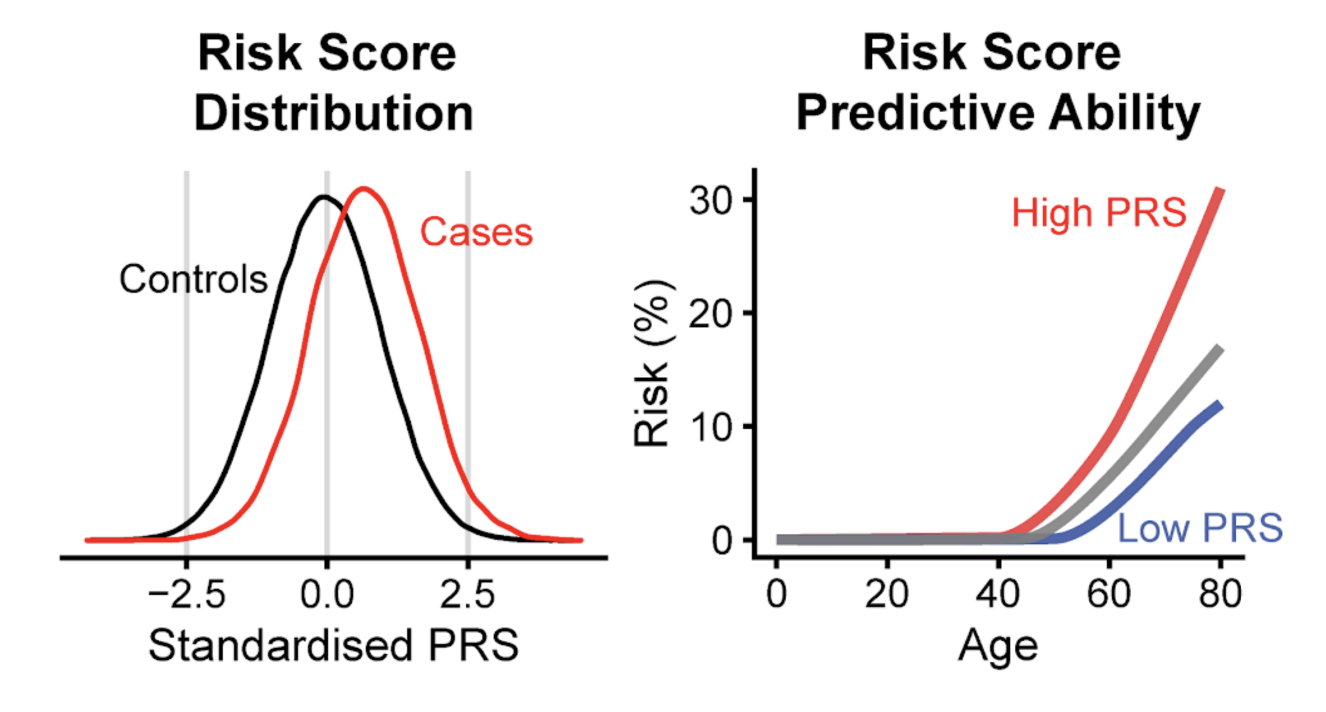

In [1]:
from IPython.display import Image, display
display(Image(filename="../docs/static/figures/PGS_Illustration.png", width=650))

**How do we compute PGSs?**

By now you are likely quite familiar with GWAS, and you know that it gives you, for each variant in the genome, an estimate effect size ($\beta$, the regression coefficient), describing how much each allele copy affects the phenotype.

| Variant | Effect allele | $\beta$ (effect size) | Individual's dosage |
|---------|---------------|------------------------|---------------------|
| SNP 1   | A             | $+0.15$                | 2                   |
| SNP 2   | T             | $-0.08$                | 1                   |
| SNP 3   | G             | $+0.22$                | 0                   |
| SNP 4   | C             | $+0.05$                | 2                   |
| SNP 5   | A             | $-0.12$                | 1                   |

Dosage here refers to the number of effect alleles an individual carries for a given variant. Now, if we have the actual genotypes for individuals, we can for example compute the score via a weighted sum of the dosages and the effect sizes:

In [2]:
import numpy as np
betas = np.array([0.15, -0.08, 0.22, 0.05, -0.12])
dosage = np.array([2, 1, 0, 2, 1])
print(f"PGS = {(betas * dosage).sum():.2f}")

PGS = 0.20


*In reality it's not quite this simple.* Real PGSs might use millions of variants, and complications include:

- **Linkage disequilibrium (LD)**: Nearby variants are correlated and might be tagging a single causal signal. Summing up all of them double counts that actual affect.
- **Noisy effect sizes:** Many GWAS $\beta$ estimates are small and noisy. Including them almost certainly hurts predictive performance, it's likely better to either need to downweight or drop them.

These, and other issues, have driven the development of a whole family of advanced and useful PGS methods, which differ in the way they handle the issues above:

- [Clumping + thresholding (C+T)](https://www.cell.com/ajhg/fulltext/S0002-9297(19)30422-7?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0002929719304227%3Fshowall%3Dtrue)
- [LDpred](https://www.cell.com/ajhg/fulltext/S0002-9297(15)00365-1?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0002929715003651%3Fshowall%3Dtrue) / [LDpred2](https://academic.oup.com/bioinformatics/article/36/22-23/5424/6039173?login=false)
- [PRS-CS](https://www.nature.com/articles/s41467-019-09718-5)

**Challenges with PGS**

While PGS have the potential to advance clinical decision making and help us understand biology, there are still numerous challenges that remain. Many of these have to do with the fact that most GWAS studies are performed in individuals of European ancestries, and as it turns out, these do not necessarily transfer/predict well into other ancestries.

***Question for you**: Let us imagine we perform a GWAS in a European centric population for a trait (e.g. HDL cholesterol), and we find that a PGS from this GWAS performs well at predicting the trait in a held-out test set from the same population. Now, let us imagine we use the same approach but now we apply it to a population more genetically distant from the population we derived the GWAS, and the performance drops significantly. Why might this be? What does this tell us about the $\beta$ values we derived in the GWAS? What would we expect if they were truly causal, and reflecting actual, human biological mechanisms?*

- **Ancestry transferability**:
    - *"[...] More than 85% of GWAS have been undertaken in individuals of European ancestries, and PRSs derived from these studies can be substantially less predictive for other genetic ancestries, potentially exacerbating health disparities."* (from [Principles and methods for transferring polygenic risk scores across global populations](https://www.nature.com/articles/s41576-023-00637-2)).
    - [Clinical use of current polygenic risk scores may exacerbate health disparities](https://www.nature.com/articles/s41588-019-0379-x)
- **Even within a specific ancestry, there can be many different types of confounding effects**
    - [Variable prediction accuracy of polygenic scores within an ancestry group](https://elifesciences.org/articles/48376)
    - [Fine-scale population structure and widespread conservation of genetic effect sizes between human groups across traits](https://www.nature.com/articles/s41588-024-02035-8)
- **There is a ceiling on what any given PGS can explain**
    - An additive PGS can not explain more than the trait's narrow sense heritability ($h^2 = \frac{V_A}{V_P}$ where $V_A$ is genetic variation due to additive effects and $V_P$ is the total phenotypic variation). This is a fundamental limit of the trait's genetic architecture, not something that bettter additive methods or more data can go beyond.
    - See [Pitfalls of predicting complex traits from SNPs](https://pubmed.ncbi.nlm.nih.gov/23774735/) and [Estimating Trait Heritability](https://www.nature.com/scitable/topicpage/estimating-trait-heritability-46889).
- **Clinical utility is an open question and a work in progress**
    - *"Polygenic risk scores performed poorly in population screening, individual risk prediction, and population risk stratification. Strong claims about the effect of polygenic risk scores on healthcare seem to be disproportionate to their performance."*
    - [Performance of polygenic risk scores in screening, prediction, and risk stratification: secondary analysis of data in the Polygenic Score Catalog](https://bmjmedicine.bmj.com/content/2/1/e000554)
 

**Additional resources**

- [Wikipedia article on polygenic scores](https://en.wikipedia.org/wiki/Polygenic_score)
- [Tutorial: a guide to performing polygenic risk score analyses](https://www.nature.com/articles/s41596-020-0353-1)
- [Polygenic risk scores: from research tools to clinical instruments ](https://link.springer.com/article/10.1186/s13073-020-00742-5)
- [The Polygenic Score Catalog as an open database for reproducibility and systematic evaluation](https://www.nature.com/articles/s41588-021-00783-5)

## 1.2 From PGS to foundation models

Classical PGS is generally one trait at a time. One would run (or download) a GWAS for HDL cholesterol, derive a scoring method from the summary statistics, apply it to individuals. If one also wants a score for LDL, one would repeat the process for a LDL-specific GWAS results.

A foundation-style model takes a slightly different approach. Rather than building one model per trait, we train a single neural network on individual-level genotype-phenotype data for multiple traits at once, so the model learns a shared representation of the genome that can be used for multiple traits simultaneously. Once trained, we can apply the trained model to a new cohort (i.e., the genotypes in the new cohorts are inputs to the trained model), and for every individual in that new cohort, we get predictions for hundreds or thousands of traits at the same time.

**What this can, and cannot do**

- **PGS-style use**: For any given single trait the model was trained on, we can use its output directly as a polygenic score, and evaluate it (given we have the true labels in our new cohort/dataset). We will see some examples of this later in the notebook for e.g. HDL and CAD.
- **Phenome-wide prediction**: The same prediction command/workflow produces predictions for every trait the model was trained on. Instead of devoting time to gather and process individual GWAS results across hundreds of traits, there is essentially additional zero development cost whether researchers are interested in a single trait or multiple.
- **Multi-trait profiling of individuals**: Having predictions for multiple traits enables different types of questions compared to a single trait. For example, instead of *what's this person's risk for disease X?*, we can explore questions like *what does this person's entire genetic profile look like across hundreds of traits?*. Useful for clustering individual, identifying outliers across multiple traits, etc.]
- **(Potentially) non-additive effects**: Neural networks can in theory capture genetic effects beyond the additive narrow sense heritability such as dominance and epistasis that additive PGS methods cannot capture directly. Whether this translates into concrete accuracy gains for complex traits is debated ([1](https://journals.plos.org/plosgenetics/article?id=10.1371/journal.pgen.1000008), [2](https://pubmed.ncbi.nlm.nih.gov/25683123/)) - but research is ongoing ([3](https://academic.oup.com/nar/article/51/12/e67/7177885), [4](https://www.biorxiv.org/content/10.1101/2025.10.26.684578v1)).

Overall, we view these types of foundation models as *complementary tools* to the already established PGS in the genetic prediction toolbox. For maximizing accuracy on an additive complex trait where well powered GWAS exist, well-tuned methods like LDpred2 or PRS-CS often match or exceed multi-task foundation model performance on the given trait. One value of the foundation style model the capability to capture and predict hundreds of traits in one go, and in practice one might use both. For example ensemble predictions (where one averages predictions from both classical and foundation models) generally perform better than either alone, indicating that the two methods are capturing different signals. 

## 1.3 What you will do here

For the rest of this noteboo, we will go through using a pretrained EIR-FM model end-to-end to predict around ~300 phenotypes on a real external cohort. We will not be training the model here, that has already been done and would require a large individual level dataset (such as the UK Biobank) and a GPU accelerator. This model has already been trained on the UK Biobank, we will download this model, apply it to a new dataset (PennCATH) and explore the predictions.

Specifically, we will:

- **Run inference with the pre-trained foundation model**: This uses the PennCATH genotype data as input, and using the `eirpredict` command will produce the ~300 trait predictions per individual.
- **Load and merge**: This will load the *real* measured included in the PennCATH cohort. This we can use as a ground truth to evaluate the predictions in various ways.
- **Evaluate continuous predictions**: HDL, LDL and triglycerides were measured in the PennCATH cohort, we can e.g. examine how these correlate with the matching predicted phenotypes, same as one would generally do in a PGS/PRS study.
- **Quantify how much the predicted phenotypes add beyond baseline covariates**: By comparing a baseline regression model (e.g. age and sex only) with one that includes the predicted phenotype, we can compute something called *incremental $R^2$* that allows us to examine how much predicted values actually add beyond basic covariates.
- **Evaluate binary disease prediction** for coronary artery disease (CAD), using a similar approach as we did with the lipid phenotypes, but this time exploring a binary (classification) target, and how we can use ROC-AUC and precision-recall curves, applying the same incremental approach as for the continuous phenotypes.
- **Explore all the predicted phenotypes**: We can explore the "phenome" generally, to see how traits that were not even measured in PennCATH relate to each other, we can do clustering and visualize how individuals relate to each other via PCA and UMAP.

**Dataset**

We will use the PennCATH cohort. The cohort is described [here](https://pmc.ncbi.nlm.nih.gov/articles/PMC3297116/), and the version we use contains 1,401 individuals on the GRCh38 (hg38) build, with measured phenotypes for CAD status, age, sex, triglycerides, HDL cholesterol and LDL cholesterol. Note that since this is a relatively small cohort by today's standards, it is very unlikely one could get a powerful enough GWAS or trained a model from scratch on this data. However, we can take the information learned in the UKB (n=~500K) and transfer that into this cohort to allow for some interesting analysis.

**Software**

We will use the [EIR-auto-GP](https://github.com/arnor-sigurdsson/EIR-auto-GP) software, which itself is built on the [EIR](https://github.com/arnor-sigurdsson/EIR) deep-learning toolkit. We will not have time to go deeply into describing these software packages in the lesson today, but put briefly:

- **EIR** is a software package that automates a lot of the boilerplate stuff around general training and inference with deep learning models. It allows one to train multi-modal deep learning models directly from the command line via `.yaml` configuration files.
- **EIR-auto-GP** is a software package that is built on top of (as in, uses) EIR, but specializes in applications for genomic prediction / PGS / PRS.

*Some Terminology*

- **GRS (Genomic representation score)**: This is a term we coined in the group to describe the full vector of predicted phenotypes/scores for a given individual. For example, you will see below that we are predicting 315 phenotypes for each individual in the dataset. As such, a given 315-element vector of scores for a given individual is that individual's "GRS".

# 2. Data setup

In [3]:
# !uv pip install gdown
# !uv pip install umap-learn

import gdown

In [4]:
model_zip_id = "1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W"
output = "../reference_data/models/"
gdown.download(id=model_zip_id, output=output)

Downloading...
From (original): https://drive.google.com/uc?id=1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W
From (redirected): https://drive.google.com/uc?id=1hRnULP7o8nOdWUzp4uJQcqnKZakuFJ3W&confirm=t&uuid=70376ed2-9042-4879-8caf-ef76c6d56958
To: /Users/vjx856/Documents/Git/integrative_post_gwas_methods_course/reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip


  0%|          | 0.00/1.53G [00:00<?, ?B/s]

  0%|          | 524k/1.53G [00:00<13:17, 1.92MB/s]

  0%|          | 2.10M/1.53G [00:00<03:57, 6.43MB/s]

  0%|          | 5.24M/1.53G [00:00<01:46, 14.3MB/s]

...

 99%|█████████▉| 1.52G/1.53G [01:24<00:00, 18.0MB/s]

100%|█████████▉| 1.52G/1.53G [01:24<00:00, 21.1MB/s]

100%|█████████▉| 1.53G/1.53G [01:25<00:00, 18.3MB/s]

100%|██████████| 1.53G/1.53G [01:25<00:00, 17.9MB/s]

'../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip'

In [5]:
penncath_hg38_id = "1d1phne1USPa7gkj7LOneyFH9zcGexvHs"
output = "../reference_data/"
gdown.download(id=penncath_hg38_id, output=output)

Downloading...
From (original): https://drive.google.com/uc?id=1d1phne1USPa7gkj7LOneyFH9zcGexvHs
From (redirected): https://drive.google.com/uc?id=1d1phne1USPa7gkj7LOneyFH9zcGexvHs&confirm=t&uuid=8f707aee-1505-45b7-8f92-3f93105a585f
To: /Users/vjx856/Documents/Git/integrative_post_gwas_methods_course/reference_data/penncat_hg38.zip


  0%|          | 0.00/143M [00:00<?, ?B/s]

  0%|          | 524k/143M [00:00<01:26, 1.64MB/s]

  1%|▏         | 2.10M/143M [00:00<00:23, 5.89MB/s]

  2%|▏         | 3.15M/143M [00:00<00:20, 6.71MB/s]

...

 95%|█████████▌| 136M/143M [00:06<00:00, 28.2MB/s]

 98%|█████████▊| 139M/143M [00:06<00:00, 28.9MB/s]

100%|█████████▉| 143M/143M [00:06<00:00, 29.3MB/s]

100%|██████████| 143M/143M [00:06<00:00, 21.0MB/s]

'../reference_data/penncat_hg38.zip'

In [6]:
!unzip -o ../reference_data/penncat_hg38.zip -d ../reference_data

Archive:  ../reference_data/penncat_hg38.zip
  inflating: ../reference_data/penncath_hg38/penncath.csv  
  inflating: ../reference_data/penncath_hg38/penncath.bim  


  inflating: ../reference_data/penncath_hg38/penncath.bed  


  inflating: ../reference_data/penncath_hg38/penncath.fam  


# 3. Prediction

Notice above how we downloaded this perhaps weirdly named `ext_d_inf_moe_general_16L-FUS_multitask.zip` file? These are trained neural network weights, where the model was trained on the UK Biobank to predict hundreds of traits from genotype data (e.g. anthropometrics, diseases, lipids, etc.). After downloading this file, and preparing our individual level genotype data, we can pass both of them to the `eirpredict` command that predicts into the PennCATH dataset.

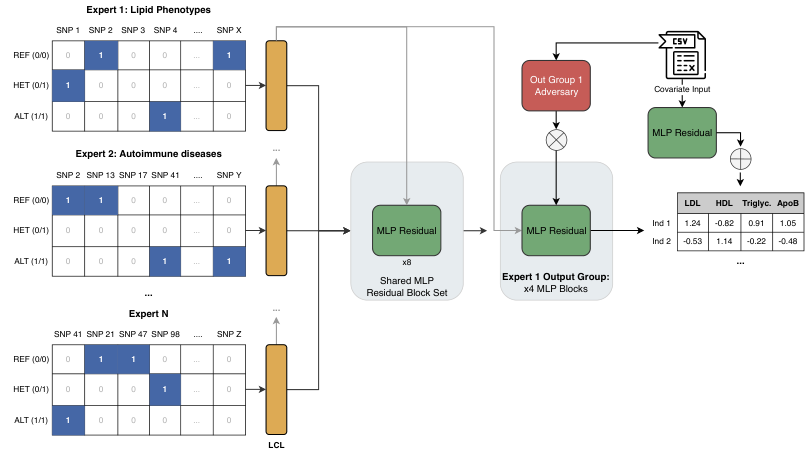

In [7]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../docs/static/figures/eir_fm_architecture.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

First we ensure the proper EIR version (one used to train the original model) is installed.

In [8]:
import importlib.metadata as m
if not m.version("eir-dl").startswith("0.23"):
    !uv pip install "git+https://github.com/arnor-sigurdsson/EIR.git@b959bfa"

Then we run the actual prediction.

**Note**: The command below might take a couple of seconds before it starts to print anything on the screen, as the necessary deep-learning software libraries are loaded. 

In [9]:
!eirautogppredict --genotype_data_path ../reference_data/penncath_hg38 --packed_experiment_path ../reference_data/models/ext_d_inf_moe_general_16L-FUS_multitask.zip --output_folder ../output

20:01:17 - WARNING - eir_auto_gp.predict.prepare_data - PLINK2/PLINK not available, skipping pre-filtering
20:01:17 - INFO - eir_auto_gp.predict.data_preparation_utils - Analyzing SNP overlap including strand/ambiguity checks...




                          SNP Overlap Analysis Report                           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric                                             ┃ Value                   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ COVERAGE METRICS                                   │                         │
│   Original Training SNPs Recovered (Main)          │ 39.5%                   │
│   New Cohort SNPs Usable (of total)                │ 11.0%*                  │
│                                                    │                         │
│ MATCHING DETAILS                                   │                         │
│   Total Matching SNPs                              │ 94,528                  │
│     - Exact Matches (A/G -> A/G)                   │ 31,513 (33.3%)          │
│     - Allele Reversals (A/G -> G/A)                │ 15,743 (16.7%)          │
│     - Strand Flips (A/G 

20:01:18 - WARNING - eir_auto_gp.predict.prepare_data - Dropping 1 ambiguous (palindromic) SNPs.


20:01:18 - INFO - eir_auto_gp.predict.prepare_data - Matching Stats: Exact=31513, Reversal=15743, StrandFlip=31404, Flip+Rev=15868


20:01:22 - INFO - plink_pipelines.make_dataset - Processed 256 samples.


...

20:02:05 - INFO - eir.setup.input_setup_modules.setup_omics - Using 239463 SNPs from subset file ../output/unpacked_experiment/modelling/fold_0/serializations/omics_input_serializations/genotype/expert_snp_groups.yaml.


20:02:05 - INFO - eir.setup.input_setup_modules.setup_omics - Set up 83 expert SNP groups from '../output/unpacked_experiment/modelling/fold_0/serializations/omics_input_serializations/genotype/expert_snp_groups.yaml'. Union contains 239463 SNPs. Expert sizes: {'cat_cluster_1': 5875, 'cat_cluster_10': 982, 'cat_cluster_11': 355, 'cat_cluster_12': 549, 'cat_cluster_13': 132, 'cat_cluster_14': 897, 'cat_cluster_15': 2042, 'cat_cluster_16': 1488, 'cat_cluster_17': 1558, 'cat_cluster_18': 4081, 'cat_cluster_19': 1001, 'cat_cluster_2': 5088, 'cat_cluster_20': 25, 'cat_cluster_21': 38, 'cat_cluster_22': 5, 'cat_cluster_23': 404, 'cat_cluster_24': 5, 'cat_cluster_25': 91, 'cat_cluster_26': 43, 'cat_cluster_27': 1798, 'cat_cluster_28': 17, 'cat_cluster_29': 31, 'cat_cluster_3': 1900, 'cat_cluster_30': 39, 'cat_cluster_31': 232, 'cat_cluster_32': 18, 'cat_cluster_33': 59, 'cat_cluster_34': 1, 'cat_cluster_4': 38, 'cat_cluster_5': 1488, 'cat_cluster_6': 1643, 'cat_cluster_7': 262, 'cat_cluster_8

20:02:05 - INFO - eir.data_load.datasets - Filtered out 0 samples that had no inputs or no target labels.
20:02:05 - INFO - eir.data_load.datasets - Using total of 1401 samples with following counts per modality (note missing tabular modalities have been imputed already):
Available genotype: 1401 (missing: 0, missing IDs: [])
20:02:05 - INFO - eir.data_load.storage_engine - Test/Validation input storage is using 0.2352MB of memory holding 1401 samples.


20:02:11 - INFO - eir.models.model_setup_modules.model_io - Encountered incompatible modules when loading model from '../output/unpacked_experiment/modelling/fold_0/saved_models/fold_0_checkpoint_15000_perf-average=0.3469.pt'.
Missing keys: 
[]
Unexpected keys: 
['input_modules.eir_tabular.embed_Assessment_Centre.weight', 'input_modules.eir_tabular.embed_Genotype_Array_BiLEVE.weight', 'input_modules.eir_tabular.embed_Sex.weight', 'input_modules.eir_tabular.layer.weight', 'input_modules.eir_tabular.layer.bias', 'input_modules.eir_tabular.mlp_blocks.0.norm_1.weight', ...]
This is expected if you are loading select modules from a saved model, which means you can ignore this message. If you are loading a pre-trained model as-is, then this is most likely an error and something unexpected has changed between the pre-training and setting up the current model from the pre-trained one.
20:02:11 - INFO - eir.models.model_setup_modules.model_io - Successfully loaded 7102/7701 modules from ../outp

20:02:11 - INFO - eir.train_utils.accelerator - Using accelerator: MPSAccelerator (auto-determined from 'auto')
20:02:11 - INFO - eir.train_utils.accelerator - Using strategy: SingleDeviceStrategy (auto-determined from 'auto')
20:02:11 - INFO - eir.train_utils.accelerator - Using precision: 32-true
20:02:11 - INFO - eir.train_utils.accelerator - Using devices: 1 (auto-determined from 'auto')
20:02:11 - INFO - eir.train_utils.accelerator - Using num_nodes: 1
20:02:11 - INFO - eir.train_utils.accelerator - Running in single-process mode


The log above here can certainly appear daunting, and most of it we can safely ignore. However, the table there includes some interesting information, specifically related to harmonizing/matching the SNPs between what the model was originally trained on (the UKB genotype data) and what is available in the target cohort (PennCATH). This step is necessary to ensure the model sees that that matches what is was originally trained on. 

For example, let's imagine a simple linear regression model, and in the "training" cohort we have SNPs `[A, D, E]` and in the target cohort we have SNPs `[A, B, C, D, E, F]`, we would then subset our target cohort to use only `[A, D, E]` when we pass the individual level SNPs to the model. The same concept applies here for the type of DL model we are using, we have to make sure the SNPs match up as well as we can. Additionally, it's very possible that in the target cohort, we simply do not have the information for SNP `A` at all.

> Note: Transformers and sequence based DL models generally can be much more robust to the order in which things appear it, assuming they are trained with that in mind, as we will see in the transformer lesson.

So, in our case, the PennCATH genotype data we are working with is composed of 861,221 SNPs, and of these, 94,528 are "usable" becuase they match with the SNPs the pre-trained UKB model was trained on:

```
INFO - eir_auto_gp.predict.prepare_data - Applying PLINK pre-filtering (94528/861221 SNPs matched)
```

If `plink2` is installed, the `EIR-auto-GP` software does a small optimization/preprocessing to subset the PennCATH genotype data PLINK files to only these 94,528 before further processing is done

**Question**: Try tracing through the log and table above, can you deduct how many SNPs were originally used to train the UKB model?

# 4. Analysis

Now that we have generated the predictions for the ~300 traits, we can start to analyze them.
Now, even though we have the ~300 predictions for each individual in PennCATH, only a few traits (3 lipids and CAD status) were actually measured in the cohort.
We will start with these 4 traits, where we have some ground truth to measure against, before doing a more broad analysis where we explore all the predicted phenotypes together.

## 4.1 Imports and setup

In [10]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/penncath_hg38/penncath.csv")

In [11]:
def load_trait_csv(path: Path) -> pd.Series:
  df = pd.read_csv(path).set_index("ID")
  trait = path.stem
  prob1 = [c for c in df.columns if c.endswith("Ensemble Prob 1")]
  if prob1:
      s = df[prob1[0]].rename(trait)
      s.attrs["kind"] = "binary"
      return s
  ensemble = [c for c in df.columns if re.fullmatch(rf"{re.escape(trait)} Ensemble", c)]
  if not ensemble:
      raise ValueError(f"No ensemble column found in {path.name}: {list(df.columns)}")
  s = df[ensemble[0]].rename(trait)
  s.attrs["kind"] = "continuous"
  return s

## 4.2 Loading in the predictions

When we use the `eirpredict` command, the model generates prediction for each individual, for each target phenotype the model was originally trained for. Each predicted phenotype results in a single `.csv` file saved on the disk. The `... Ensemble` column is the average of training multiple folds (i.e. slightly different versions of the model, which allows estimating uncertainty in any given prediction among other things), since we only have a single fold in this case, the `... Ensemble` column is the same as the `Fold 0` column.

In [12]:
!ls "../output/results" | head

Alanine_aminotransferase.csv
Albumin_BIOCH.csv
Alkaline_phosphatase.csv
Apolipoprotein_A.csv
Apolipoprotein_A1.csv
Apolipoprotein_B_BIOCH.csv
Apolipoprotein_B_METAB.csv
Aspartate_aminotransferase.csv
Average_Diameter_for_HDL_Particles.csv
Average_Diameter_for_VLDL_Particles.csv


In [13]:
!head "../output/results/Alanine_aminotransferase.csv"

ID,Alanine_aminotransferase Fold 0,Alanine_aminotransferase Ensemble
10002,22.54277,22.54277
10004,28.100965,28.100965
10005,22.484835,22.484835
10007,23.97966,23.97966
10008,26.343996,26.343996
10009,26.697598,26.697598
10010,21.769468,21.769468
10011,22.51627,22.51627
10012,22.866842,22.866842


The code below essentially gathers upp all these `.csv` files for all the predicted phenotypes into a single data frame, so for each of the 1,401 individuals in the PennCATH dataset, we end up with 315 (237 continuous and 78 binary) "features" (i.e., predicted phenotypes / GRSs).

In [14]:
series_list, kinds = [], {}
for p in sorted(RESULTS_DIR.glob("*.csv")):
  s = load_trait_csv(p)
  series_list.append(s)
  kinds[s.name] = s.attrs["kind"]

preds = pd.concat(series_list, axis=1)
trait_kind = pd.Series(kinds, name="kind")
print(f"preds: {preds.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")
display(preds.head())

preds: (1401, 315)  continuous=237  binary=78


,Alanine_aminotransferase,Albumin_BIOCH,Alkaline_phosphatase,Apolipoprotein_A,Apolipoprotein_A1,Apolipoprotein_B_BIOCH,Apolipoprotein_B_METAB,Aspartate_aminotransferase,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,...,Urea,VLDL_Cholesterol,Vitamin_D,Waist_circumference,Weight_ANTHRO,Weight_IMPED,White_blood_cell_leukocyte_count,Whole_body_fat_free_mass,Whole_body_fat_mass,Whole_body_water_mass
ID,,,,,,,,,,,,,,,,,,,,,
10002,22.542770,45.750916,78.095764,1.516815,1.461326,1.079866,0.920252,25.107138,9.593956,38.873093,...,5.371122,0.798058,49.158367,92.140720,80.53792,80.50510,6.893251,54.358200,26.746830,39.798134
10004,28.100965,44.744290,82.361740,1.553589,1.489705,0.935423,0.784924,26.449203,9.604637,38.699020,...,5.384340,0.621664,46.077310,88.349655,76.54702,76.31497,6.289234,52.096508,23.333853,37.992413
10005,22.484835,45.355780,90.182304,1.544894,1.473571,1.035341,0.870705,27.218803,9.558011,39.674297,...,5.420731,0.774767,50.846190,90.930595,76.09740,75.78765,6.923183,51.953290,26.081810,37.976200
10007,23.979660,45.518280,87.363410,1.639348,1.566334,1.016251,0.852204,24.755083,9.717243,38.340710,...,5.477870,0.692197,45.338993,87.590614,70.78199,70.52157,6.385489,49.508488,22.894985,36.236700
10008,26.343996,46.066658,88.195015,1.447073,1.392570,1.073851,0.893995,26.636324,9.563436,38.972090,...,5.484081,0.751684,54.548225,87.538025,78.50737,78.36777,6.650043,52.501266,23.214048,38.252075


## 4.3 Loading the actual, measured PennCATH labels

Here we load in the *actual* measured phenotypes in the PennCATH, which we will compare and analyze with the predicted values from the UKB trained model.

In [15]:
labels = pd.read_csv(LABELS_PATH).set_index("ID")
print(f"labels: {labels.shape}")
display(labels.head())

labels: (1401, 6)


,CAD,sex,age,tg,hdl,ldl
ID,,,,,,
10002,1,1,60,NaN,NaN,NaN
10004,1,2,50,55.0,23.0,75.0
10005,1,1,55,105.0,37.0,69.0
10007,1,1,52,314.0,54.0,108.0
10008,1,1,58,161.0,40.0,94.0


Alright, so far we have:

1. Downloaded and set-up a DL model pre-trained on the UKB data, that takes individual genotype data as input, and outputs 315 phenotypes, both categorical and continuous
2. Downloaded the individual PennCATH genotype data for 1,401 individual
3. Passed the individual PennCATH genotypes to the DL model, which procuces a vector of 315 predicted values (i.e. the GRS vector) for each of the 1,401 individuals.
4. Loaded in the *actual* phenotypes/labels included in the PennCATH data

Before we go further, it's probably a good idea take a quick look at the labels themselves.

### 4.3.1 Exploratory data analysis (EDA) of PennCATH labels

In [16]:
labels["CAD"].value_counts()

CAD
1    933
0    468
Name: count, dtype: int64

**Question:** What is the cell above telling us? If `1` is a positive CAD diagnosis - does this reflect what we might find in a randomly drawn sample of a population? If someone comes to you and says they have made a great model that is 66% accurate in this cohort, why might that be suspicious?

Next, let's examine how the CAD prevalence changes as a function of age. 

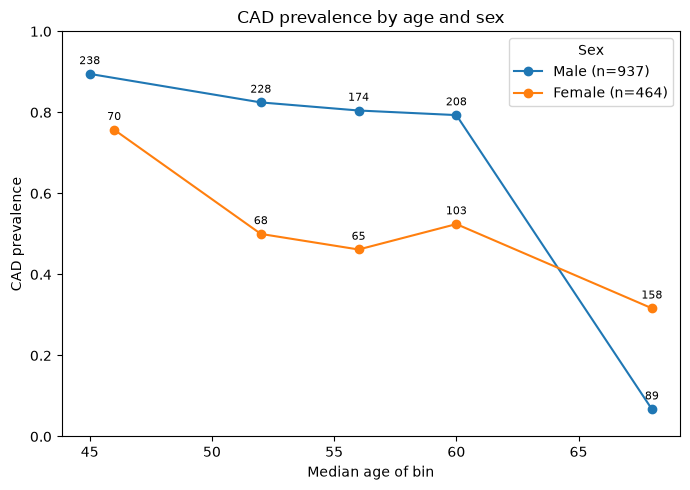

In [17]:
sex_names = {1: "Male", 2: "Female"}
n_bins = 5

labels["age_bin"] = pd.qcut(labels["age"], q=n_bins)

edges = labels["age_bin"].cat.categories

fig, ax = plt.subplots(figsize=(7, 5))
for sex_code, sex_label in sex_names.items():
    
    sub = labels[labels["sex"] == sex_code]
    grp = sub.groupby("age_bin", observed=True)
    prev = grp["CAD"].mean()
    med_age = grp["age"].median()
    n = grp.size()
    
    ax.plot(med_age.values, prev.values, marker="o", label=f"{sex_label} (n={n.sum()})")
    for x, p, cnt in zip(med_age.values, prev.values, n.values):
        ax.annotate(str(cnt), (x, p), textcoords="offset points", xytext=(0, 7), fontsize=8, ha="center")

ax.set_xlabel("Median age of bin")
ax.set_ylabel("CAD prevalence")
ax.set_ylim(0, 1)
ax.legend(title="Sex")
ax.set_title("CAD prevalence by age and sex")
fig.tight_layout()
plt.show()

**Question:** Is this pattern expected? That CAD *decreases* with age? Why might we be seeing this result? Here is an extract from the [PennCATH article](https://pmc.ncbi.nlm.nih.gov/articles/PMC3297116/) itself that might give us a hint:

> *"The webappendix shows a detailed description of design and clinical characteristics for
study samples (pp 2–4). Our primary focus was on studies of angiographic CAD in patients
of European ancestry. Discovery studies were PennCath and MedStar (webappendix p 2),
which recruited patients before coronary angiography at the University of Pennsylvania
Medical Center (Penn) and Washington Hospital Center (WHC), respectively. Selection of
younger patients with angiographic CAD (mean age about 51±7 years) and older controls
(mean age about 61±9 years) was aligned across these two studies, which used similar
angiographic criteria and had similar numbers of cases of angiographic CAD with and
without myocardial infarction."*

## 4.4 Merging true PennCATH labels with relevant predictions

Notice above the real, measured phenotypes in PennCATH include Triglycerides (`tg`), HDL Cholesterol (`hdl`) and LDL Cholesterol (`ldl`). Luckily, we have the same phenotypes (albeit named slightly differently) in the model trained in the UKB, which allows us to directly compare the predictions for these 3 phenotypes to the real values. 

In [18]:
continuous_traits = {
    'TG': 'Triglycerides',
    'HDL': 'HDL Cholesterol',
    'LDL': 'LDL Cholesterol'
}

binary_traits = {
    'CAD': 'Coronary Artery Disease'
}

In [19]:
rename_preds = {
    'I25': 'CAD_pred',
    'Total_Triglycerides': 'TG_pred',
    'HDL_cholesterol': 'HDL_pred',
    'LDL_Cholesterol': 'LDL_pred'
}

rename_true = {
    'CAD': 'CAD_true',
    'tg': 'TG_true',
    'hdl': 'HDL_true',
    'ldl': 'LDL_true'
}

preds_copy = preds.copy().reset_index()
preds_copy = preds_copy[['ID'] + list(rename_preds.keys())]
preds_renamed = preds_copy.rename(columns=rename_preds)
true_renamed = labels.rename(columns=rename_true)

df_real_final = pd.merge(preds_renamed, true_renamed, on='ID', how='inner')
print(f"merged: {df_real_final.shape}")
display(df_real_final.head())

merged: (1401, 12)


,ID,CAD_pred,TG_pred,HDL_pred,LDL_pred,CAD_true,sex,age,TG_true,HDL_true,LDL_true,age_bin
0,10002,0.299964,1.445587,1.431592,1.888146,1,1,60,NaN,NaN,NaN,"(57.0, 62.0]"
1,10004,0.366859,1.230927,1.444633,1.623983,1,2,50,55.0,23.0,75.0,"(49.0, 54.0]"
2,10005,0.418134,1.732881,1.349207,1.733176,1,1,55,105.0,37.0,69.0,"(54.0, 57.0]"
3,10007,0.428991,1.272115,1.598767,1.763022,1,1,52,314.0,54.0,108.0,"(49.0, 54.0]"
4,10008,0.453609,1.419624,1.304491,1.781938,1,1,58,161.0,40.0,94.0,"(57.0, 62.0]"


## 4.5 Evaluation of Continuous Traits

So, as mentioned above, for the first analysis, we will compare how some of the predicted phenotypes from the UKB model above match real measured phenotypes in the cohort. Now, one thing here is that the units reported in the UKB can be different from what is reported in PennCATH. For example in the UKB, we Triglycerides measured in mmol/L whereas PennCATH might be using something else. While we can still correlate things between different units, it's a bit nicer to normalize them both (e.g. via [Z-score normalization](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html)).


In [20]:
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, roc_curve, average_precision_score, precision_recall_curve, auc
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

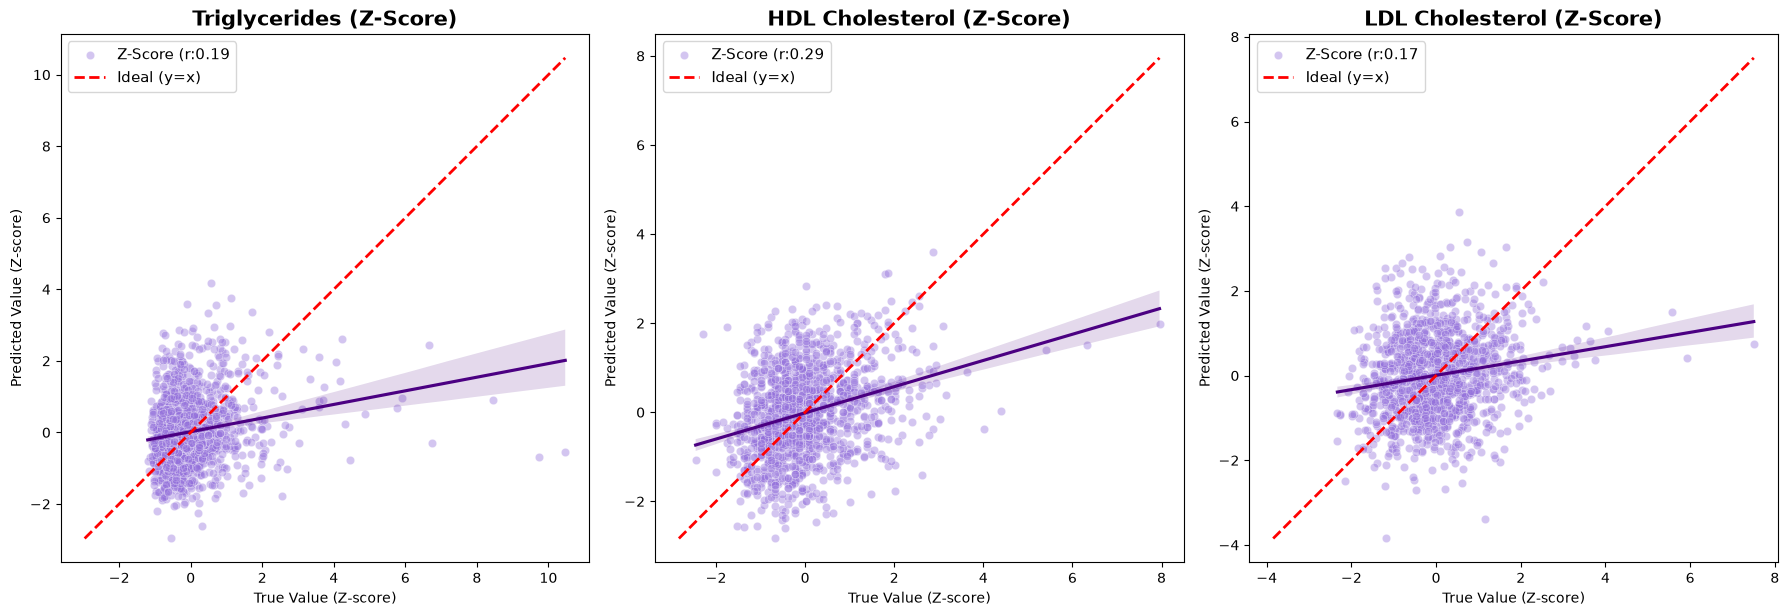

In [21]:
df_zscore = df_real_final.copy()
scaler = StandardScaler()

for trait in continuous_traits.keys():
    df_zscore[f'{trait}_true_z'] = scaler.fit_transform(df_zscore[[f'{trait}_true']])
    df_zscore[f'{trait}_pred_z'] = scaler.fit_transform(df_zscore[[f'{trait}_pred']])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, trait in enumerate(continuous_traits.keys()):
    cols = [f'{trait}_true_z', f'{trait}_pred_z']
    valid_data = df_zscore[cols].dropna()
    
    y_true_z = valid_data[f'{trait}_true_z']
    y_pred_z = valid_data[f'{trait}_pred_z']
    
    ax = axes[i]
    
    corr_z, _ = pearsonr(y_true_z, y_pred_z)
    
    label_z = f'Z-Score (r:{corr_z:.2f}'
    
    sns.scatterplot(x=y_true_z, y=y_pred_z, alpha=0.4, ax=ax, label=label_z, color='mediumpurple')
    sns.regplot(x=y_true_z, y=y_pred_z, scatter=False, ax=ax, color='indigo', )
 
    all_vals = pd.concat([y_true_z, y_pred_z])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y=x)')
    
    ax.set_title(f'{continuous_traits[trait]} (Z-Score)', fontsize=15, fontweight='bold')
    ax.set_xlabel('True Value (Z-score)')
    ax.set_ylabel('Predicted Value (Z-score)')
    
    ax.legend(loc='upper left', fontsize=11)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

This might seem like a relatively low predictive performance, but keep in mind that this is only from the genetics - for these plots here above, we are not taking into account things like age and sex, and the fact that, depending on the phenotype, the contribution of genetics can be much less than the environment.

## 4.6 Checking for counfounding - how much do predictions improve over a baseline?

As you might know, GWAS (and by extension PGS and PRS) can be famously tricky due to confounders like ancestry bias or population stratification. If our model has e.g. learned a proxy for demographic variables in the UKB genetic data, and this bias is also reflected in PennCATH then it might seem like the model is effective at predicting Triglycerides from genetic data, when when in reality, it is mostly just capturing the baseline differences in Triglycerides between males and females.

One way to check for this is to example how much the phenotype predictions *improve* over a baseline where we account for variables that we suspect might be confounding. Here below, we first fit a baseline linear model to see how much variance age and sex explain in the dataset. Then, we fit a model that uses age and sex, but *also* the prediction for the phenotype of interest. If the predicted value for e.g. Triglycerides was purely a proxy for age, we would not expect it to improve at all over the variance explained of using age and sex only.

**References:**

- [Apparent latent structure within the UK Biobank sample has implications for epidemiological analysis](https://www.nature.com/articles/s41467-018-08219-1) (discusses the importance of correcting for confounding, and how even the current approaches might not always be sufficient)
- [Tutorial: a guide to performing polygenic risk score analyses](https://www.nature.com/articles/s41596-020-0353-1) (besides being a great resource, discusses incremental R2)

In [22]:
import statsmodels.formula.api as smf

df = df_real_final.copy()

for trait, full_name in continuous_traits.items():
    y_col = f"{trait}_true"
    prs_col = f"{trait}_pred"
    
    # Base Model (age + sex)
    formula_base = f"{y_col} ~ age + sex"
    model_base = smf.ols(formula=formula_base, data=df).fit()
    r2_base = model_base.rsquared * 100
    
    # Full Model
    formula_full = f"{y_col} ~ age + sex + {prs_col}"
    model_full = smf.ols(formula=formula_full, data=df).fit()
    r2_full = model_full.rsquared * 100
    
    # Delta R2
    delta_r2 = r2_full - r2_base
    
    # P-value for the PRS term in the full model
    p_val_prs = model_full.pvalues[prs_col]
    
    print(f"[{trait} - {full_name}]")
    print(f" - Base R2 (age, sex): {r2_base:.2f}%")
    print(f" - Full R2 (+ PRS)  : {r2_full:.2f}%")
    print(f" - Delta R2         : +{delta_r2:.2f}% (p-value: {p_val_prs:.2e})\n")

[TG - Triglycerides]
 - Base R2 (age, sex): 2.91%
 - Full R2 (+ PRS)  : 5.74%
 - Delta R2         : +2.84% (p-value: 5.02e-10)

[HDL - HDL Cholesterol]
 - Base R2 (age, sex): 15.60%
 - Full R2 (+ PRS)  : 22.24%
 - Delta R2         : +6.64% (p-value: 4.75e-25)

[LDL - LDL Cholesterol]
 - Base R2 (age, sex): 1.80%
 - Full R2 (+ PRS)  : 4.70%
 - Delta R2         : +2.89% (p-value: 6.39e-10)



**Takeaway**: So here we see, for all three lipids, adding the model's predicted phenotype significantly (p < 1e-09 in all 3 cases) improves over the age+sex baseline. We see the largest gain for HDL (+6.64%) with the improvement around 2.8-2.9% for the other two lipids. This tells us that the predicted phenotype contains information *beyond* just age and sex.

## 4.7 Evaluation of Binary Traits

Given that our model can somewhat predict the lipid phenotypes above, and it does seem to improve over the age and sex covariate baselines, we can explore how well it predicts Coronary Artery Disease in PennCATH. For this, we use the I25 (which is the ICD10 code for [Chronic ischaemic heart disease](https://icd.who.int/browse10/2019/en#/I25)) disease prediction from the DL model. 

In typical ML scenarios, we often use metrics such as accuracy, F1 score etc to evaluate our models. However, in genetic prediction settings, we rarely use a hard classification threshold which is used in metrics such as accuracy (e.g. >50% prediction confidence a sample is "assigned" the positive label). Because overall prevalence for a disease like CAD might be extremely low in a population-scale  cohort, setting a rigid cut-off might simply assign all individuals being "negative" - not very useful despite giving a "high accuracy" in a imbalanced dataset. Additionally, for most disease traits, genetic predisposition acts more on a continuous spectrum (i.e., it is not that having a given allele makes it *certain* that you get a given disease)

Instead, you will often see people using:

1. **ROC-AUC** (area under the receiver operating characteristic curve, see [here](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) and [here](https://scikit-learn.org/stable/modules/model_evaluation.html#roc-metrics)) which essentially reflects whether positive samples are generally given a higher score compared to negative samples.
2. **PR-AUC**, which is another common measure (area under the precision-recall curve, see [here](https://en.wikipedia.org/wiki/Precision_and_recall#Introduction) and [here](https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html)) starts by focusing on the high scoring individuals in the dataset, and examines how precision (how many are actually positive among those high scoring individuals) is traded off for recall (how many of the total positives we are capturing) across multiple scoring thresholds. So for example, in the case where we could have an even 50/50 ratio of positives and negatives among those that the model scores highly, the precision will stay around 0.5 across that region, which ultimately lowers the area under the curve. The tradeoff is if we have few negatives, we can get artifical high PR-AUC scores, so it's often good plot the baseline rate of positives as well.

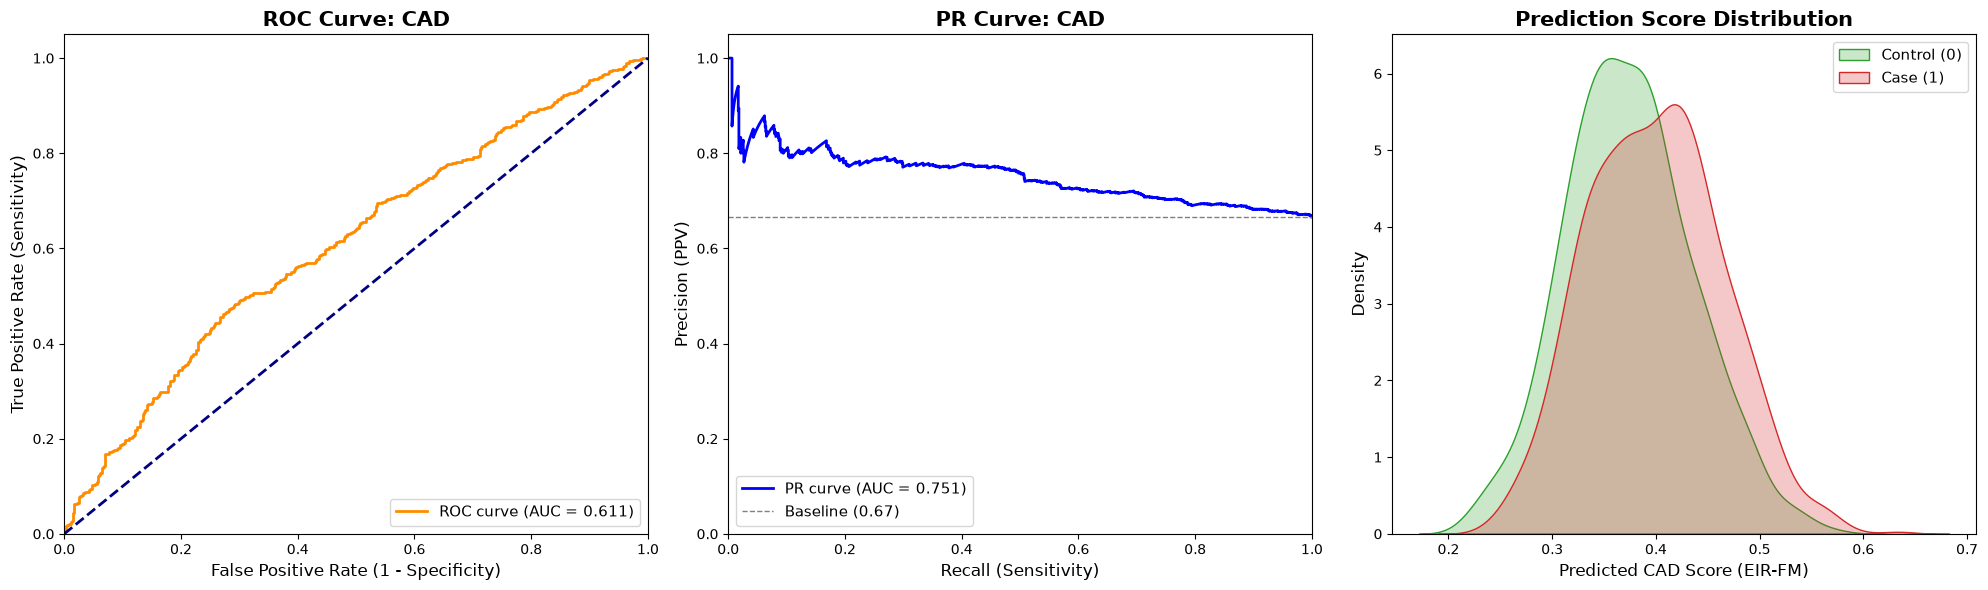

In [23]:
for trait, full_name in binary_traits.items():
    true_col = f'{trait}_true'
    pred_col = f'{trait}_pred'
    
    valid_data = df[[true_col, pred_col]].dropna()
    y_true = valid_data[true_col]
    y_score = valid_data[pred_col]
    
    roc_auc = roc_auc_score(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    axes[0].set_title(f'ROC Curve: {trait}', fontsize=15, fontweight='bold')
    axes[0].legend(loc="lower right", fontsize=11)

    axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    baseline = y_true.sum() / len(y_true)
    axes[1].axhline(y=baseline, color='gray', linestyle='--', lw=1, label=f'Baseline ({baseline:.2f})')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
    axes[1].set_ylabel('Precision (PPV)', fontsize=12)
    axes[1].set_title(f'PR Curve: {trait}', fontsize=15, fontweight='bold')
    axes[1].legend(loc="lower left", fontsize=11)

    sns.kdeplot(data=valid_data[valid_data[true_col] == 0][pred_col], 
                ax=axes[2], fill=True, color='#2ca02c', label='Control (0)')
    sns.kdeplot(data=valid_data[valid_data[true_col] == 1][pred_col], 
                ax=axes[2], fill=True, color='#d62728', label='Case (1)')
    axes[2].set_title(f'Prediction Score Distribution', fontsize=15, fontweight='bold')
    axes[2].set_xlabel(f'Predicted {trait} Score (EIR-FM)', fontsize=12)
    axes[2].set_ylabel('Density', fontsize=12)
    axes[2].legend(loc='upper right', fontsize=11)

    plt.tight_layout()
    plt.show()

In [24]:
for trait, full_name in binary_traits.items():
    y_col = f"{trait}_true"
    pred_col = f"{trait}_pred"

    # Base Model (age + sex)
    formula_base = f"{y_col} ~ age + sex"
    logit_base = smf.logit(formula=formula_base, data=df).fit(disp=0)
    
    auc_base = roc_auc_score(df[y_col], logit_base.predict(df))
    pseudo_r2_base = logit_base.prsquared * 100

    # Full Model
    formula_full = f"{y_col} ~ age + sex + {pred_col}"
    logit_full = smf.logit(formula=formula_full, data=df).fit(disp=0)
    
    auc_full = roc_auc_score(df[y_col], logit_full.predict(df))
    pseudo_r2_full = logit_full.prsquared * 100

    delta_auc = auc_full - auc_base
    delta_pseudo_r2 = pseudo_r2_full - pseudo_r2_base
    
    p_val_score = logit_full.pvalues[pred_col]

    print(f"[{trait} - {full_name}]")
    print(f" - Base Model (age, sex)")
    print(f"   * AUC: {auc_base:.4f} | Pseudo-R²: {pseudo_r2_base:.2f}%")
    
    print(f" - Full Model (+ {trait} Score)")
    print(f"   * AUC: {auc_full:.4f} | Pseudo-R²: {pseudo_r2_full:.2f}%")
    
    print(f" - Incremental Gain (Delta)")
    print(f"   * Delta AUC: +{delta_auc:.4f}")
    print(f"   * Delta R² : +{delta_pseudo_r2:.2f}% (p-value: {p_val_score:.2e})\n")

[CAD - Coronary Artery Disease]
 - Base Model (age, sex)
   * AUC: 0.7779 | Pseudo-R²: 20.51%
 - Full Model (+ CAD Score)
   * AUC: 0.7881 | Pseudo-R²: 21.96%
 - Incremental Gain (Delta)
   * Delta AUC: +0.0102
   * Delta R² : +1.45% (p-value: 5.84e-07)



## 4.8 Clustering correlated traits

So far we have only evaluated traits where we also have ground-truth measurements in PennCATH (the lipid panel and CAD). However, the model also gives us predictions for ~230 other continuous traits per individual — for the vast majority of which we do *not* have measured values to compare against. We can still learn something useful from these predictions by looking at how they relate to *each other*.

Many of these predicted phenotypes are biologically related (e.g. the lipid panel, blood cell counts, kidney markers, liver enzymes, anthropometrics), so we would expect their predictions to be correlated. Examining this correlation structure is useful for several reasons:

- **Sanity check** — biologically related traits should cluster together if the model has learned meaningful biology rather than spurious signal.
- **Identifying redundancy** — if two predicted traits are nearly perfectly correlated, one of them carries little additional information and the pair likely reflects the same underlying biological measurement.
- **Surfacing unexpected structure** — unrelated traits clustering together might point to a shared confounder (e.g. ancestry, age, sex) being captured by the model, rather than independent biological signal.

Below we compute **Spearman correlation** (rank-based, robust to non-linear monotonic relationships and to outliers) across all predicted continuous traits, and then **hierarchically cluster** the resulting matrix so that related traits end up adjacent in the heatmap. Blocks of red (positive correlation) or blue (negative correlation) along the diagonal correspond to groups of traits the model treats similarly.

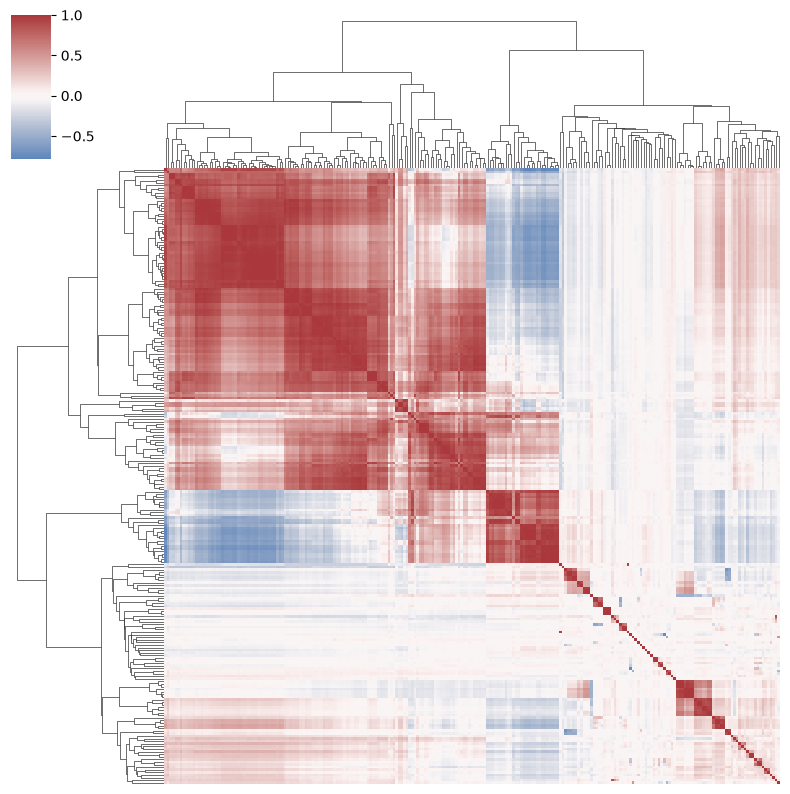

Continuous traits in correlation: 237


In [25]:
df = preds.copy()

cont_traits = trait_kind.index[trait_kind == "continuous"].tolist()
cont = df[cont_traits].apply(pd.to_numeric, errors="coerce")
cont = cont.loc[:, cont.std() > 0]
corr = cont.corr(method="spearman")

order = sns.clustermap(corr, cmap="vlag", center=0, figsize=(8, 8),
                    xticklabels=False, yticklabels=False).dendrogram_row.reordered_ind
plt.show()
print(f"Continuous traits in correlation: {corr.shape[0]}")

In [26]:
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = (corr.where(mask).stack()
            .rename("spearman").reset_index()
            .rename(columns={"level_0": "trait_a", "level_1": "trait_b"}))
pairs.sort_values("spearman", ascending=False).head(10)

,trait_a,trait_b,spearman
54979,Weight_ANTHRO,Weight_IMPED,0.997179
4538,Cholesterol_in_Large_HDL,Cholesteryl_Esters_in_Large_HDL,0.996765
15842,Concentration_of_Very_Small_VLDL_Particles,Total_Lipids_in_Very_Small_VLDL,0.996750
37646,Phospholipids_in_Very_Small_VLDL,Total_Lipids_in_Very_Small_VLDL,0.996470
2857,Body_mass_index_BMI_ANTHRO,Body_mass_index_BMI_IMPED,0.996365
14890,Concentration_of_Small_VLDL_Particles,Total_Lipids_in_Small_VLDL,0.996149
6681,Cholesterol_in_Very_Large_HDL,Cholesteryl_Esters_in_Very_Large_HDL,0.996089
5006,Cholesterol_in_Large_VLDL,Cholesterol_in_Very_Large_VLDL,0.995785
34789,Phospholipids_in_Large_HDL,Total_Lipids_in_Large_HDL,0.995528
37170,Phospholipids_in_Very_Large_HDL,Total_Lipids_in_Very_Large_HDL,0.995453


In [27]:
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = (corr.where(mask).stack()
            .rename("spearman").reset_index()
            .rename(columns={"level_0": "trait_a", "level_1": "trait_b"}))
pairs.sort_values("spearman", ascending=False).tail(10)

,trait_a,trait_b,spearman
56159,Whole_body_water_mass,Urea,NaN
56160,Whole_body_water_mass,VLDL_Cholesterol,NaN
56161,Whole_body_water_mass,Vitamin_D,NaN
56162,Whole_body_water_mass,Waist_circumference,NaN
56163,Whole_body_water_mass,Weight_ANTHRO,NaN
56164,Whole_body_water_mass,Weight_IMPED,NaN
56165,Whole_body_water_mass,White_blood_cell_leukocyte_count,NaN
56166,Whole_body_water_mass,Whole_body_fat_free_mass,NaN
56167,Whole_body_water_mass,Whole_body_fat_mass,NaN
56168,Whole_body_water_mass,Whole_body_water_mass,NaN


The table above lists the 20 most strongly correlated trait *prediction* pairs (by absolute Spearman correlation). A few patterns stand out:

- **Same biological measurement, different assays** — e.g. `Weight_ANTHRO` vs `Weight_IMPED` (anthropometric vs impedance-based weight) and `Body_mass_index_BMI_ANTHRO` vs `Body_mass_index_BMI_IMPED`. These should be near-perfectly correlated, which is a good sanity check.
- **Lipoprotein sub-fraction redundancy** — most of the remaining top pairs are different lipid components of the *same particle* (e.g. Cholesterol, Cholesteryl Esters, Free Cholesterol, Phospholipids within Large HDL or Very Small VLDL). Total lipid content of a particle class is essentially a sum of its parts, so the model output reflects that.

We can also check the top 5 positive and negatively correlated phenotypes for a given phenotype.

In [28]:
target = "Cholesterol"
pd.DataFrame(pd.concat([corr[target].sort_values(ascending=False).head(5), corr[target].sort_values(ascending=False).tail(5)]))

,Cholesterol
Cholesterol,1.000000
Total_Free_Cholesterol,0.967739
Total_Cholesterol,0.955819
Total_Lipids_in_Large_LDL,0.949706
Cholesteryl_Esters_in_Large_LDL,0.946443
Cystatin_C,-0.150212
Trunk_fat_free_mass,-0.171714
Creatinine_BIOCH,-0.193989
Vitamin_D,-0.200604
Direct_bilirubin,-0.229289


## 4.9 Cluster visualization

The correlation analysis above looked at relationships between *traits*. Here we flip the perspective and look at the relationships between *individuals*. Each individual is now represented as a vector of ~230 trait predictions, and we would like to know whether individuals form meaningful groups (e.g. by ancestry, sex, age, disease subtype) in this prediction space.

Since we cannot directly plot a 230-dimensional space, we use two complementary dimensionality reduction techniques to project each individual onto 4 components, then visualize all pairwise combinations of those components:

- **PCA (Principal Component Analysis)** — a *linear* method that finds orthogonal axes capturing maximum variance. The leading PCs often correspond to broad biological gradients (ancestry, sex, age) when applied to phenotypic data, and are useful as a first pass. The percentage on each axis label is the fraction of total variance explained by that component.
- **UMAP (Uniform Manifold Approximation and Projection)** — a *non-linear* method that preserves local neighborhood structure better than PCA, often revealing discrete clusters that get blurred together when projected linearly.

If PCA shows a smooth continuous gradient while UMAP shows discrete clumps, the two are giving you complementary views of the same underlying structure: PCA tells you about dominant axes of variation, UMAP tells you about local groupings.

> **Note**: To make the clustering more interpretable, you would typically color the points by a known covariate (sex, age decile, ancestry, case/control status). The plots below are unlabelled, but both cells start with a `color_by` variable that takes a column to color by. We have `labels["sex"]`, `labels["age"]` and `labels["CAD"]` for everyone, and `labels["tg"]`, `labels["hdl"]` and `labels["ldl"]` where the lipids were measured. Any of the 315 predictions works too, for example `preds["Standing_height"]`. Try a few and see whether the structure aligns with anything you can name.

/var/folders/mr/kxjfn6mx1kdd3j6p527gf6qw0000gn/T/ipykernel_94872/3579294091.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(pc_df[f"PC{i}"], pc_df[f"PC{j}"],


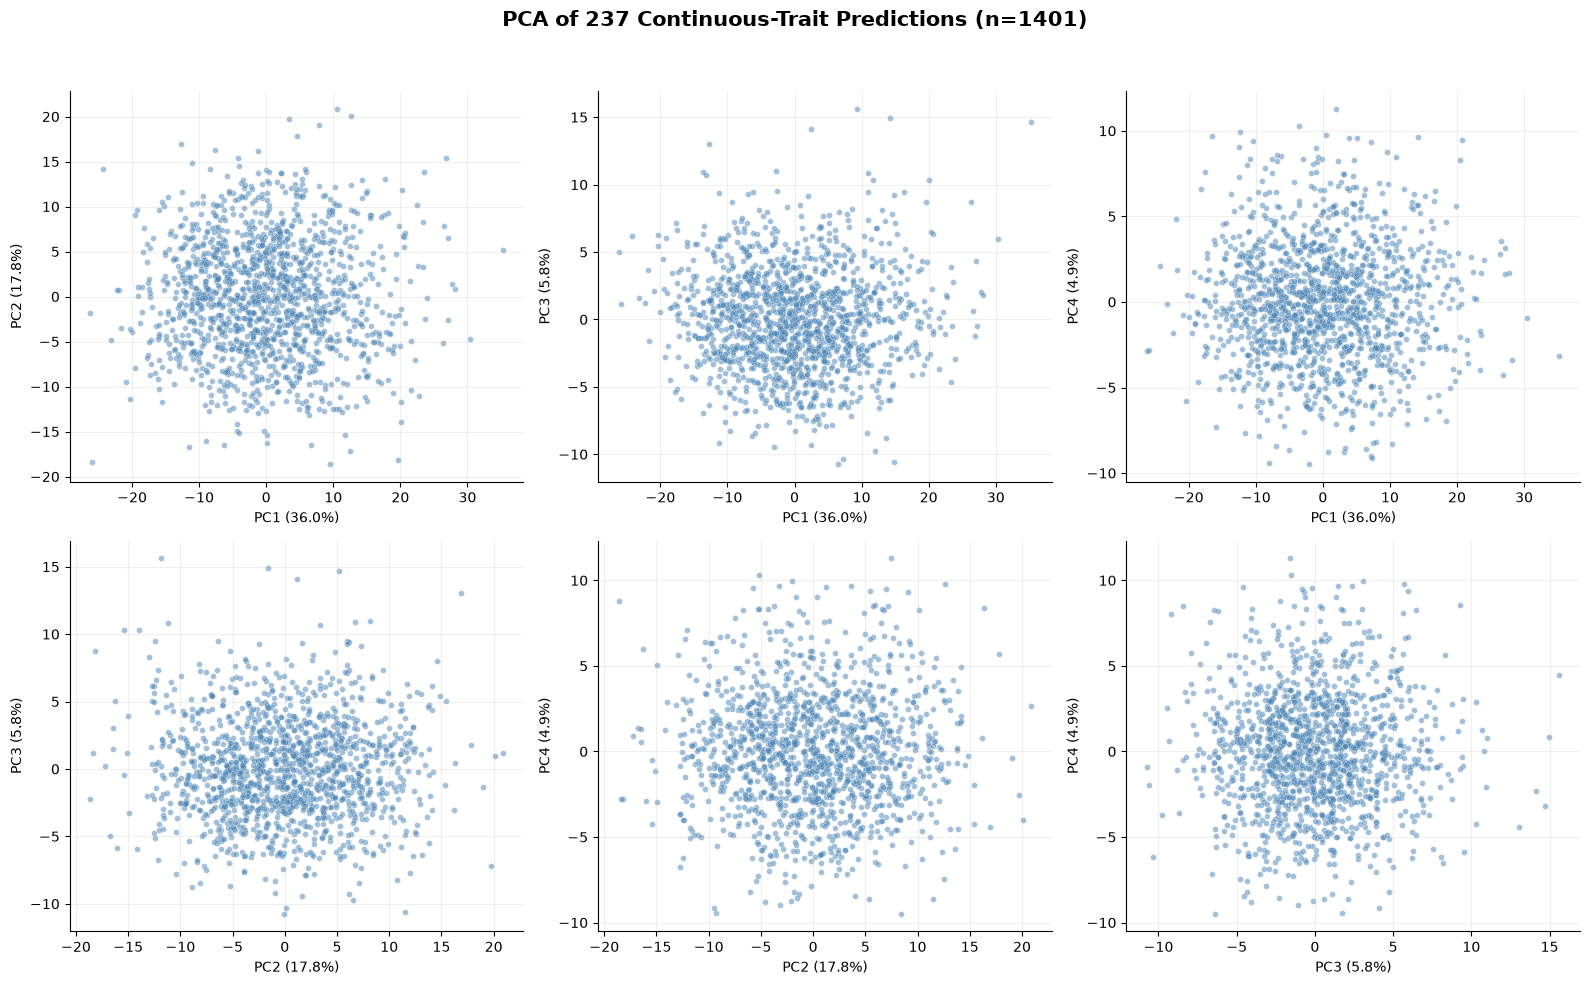

In [29]:
# To color the points, set color_by to one of the columns below and re-run this cell.
#
# Measured in PennCATH, from `labels`:
#     color_by = labels["sex"]     # 1 = male, 2 = female
#     color_by = labels["age"]
#     color_by = labels["CAD"]     # 0 = control, 1 = case
#     color_by = labels["hdl"]     # also "tg" and "ldl", missing for some individuals
#
# Predicted by the model, any of the 315 columns in `preds`:
#     color_by = preds["Standing_height"]
#     color_by = preds["I25"]      # predicted probability of chronic ischaemic heart disease
#
color_by = None

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import combinations

X_df = df[cont.columns].dropna(axis=1, thresh=int(0.95 * len(df)))
X = StandardScaler().fit_transform(X_df.values)

pca = PCA(n_components=4, random_state=0)
pcs = pca.fit_transform(X)
pc_df = pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(4)], index=X_df.index)

pairs = list(combinations(range(1, 5), 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

point_color = color_by.reindex(X_df.index) if color_by is not None else "steelblue"

for ax, (i, j) in zip(axes.flat, pairs):
    ax.scatter(pc_df[f"PC{i}"], pc_df[f"PC{j}"],
               s=18, alpha=0.5, linewidth=0.3,
               edgecolor="white", c=point_color, cmap="viridis") 
    
    var_i = pca.explained_variance_ratio_[i-1]
    var_j = pca.explained_variance_ratio_[j-1]
    
    ax.set_xlabel(f"PC{i} ({var_i*100:.1f}%)")
    ax.set_ylabel(f"PC{j} ({var_j*100:.1f}%)")
    
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)

fig.suptitle(f"PCA of {X_df.shape[1]} Continuous-Trait Predictions (n={len(pc_df)})", 
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

*For reference: PCA of the same model's predictions on the **Human Origins** dataset, which spans many continental backgrounds. If ancestry were heavily driving the predictions, we would expect populations to separate along the leading PCs. Instead the colors stay tangled across every PC pair.*

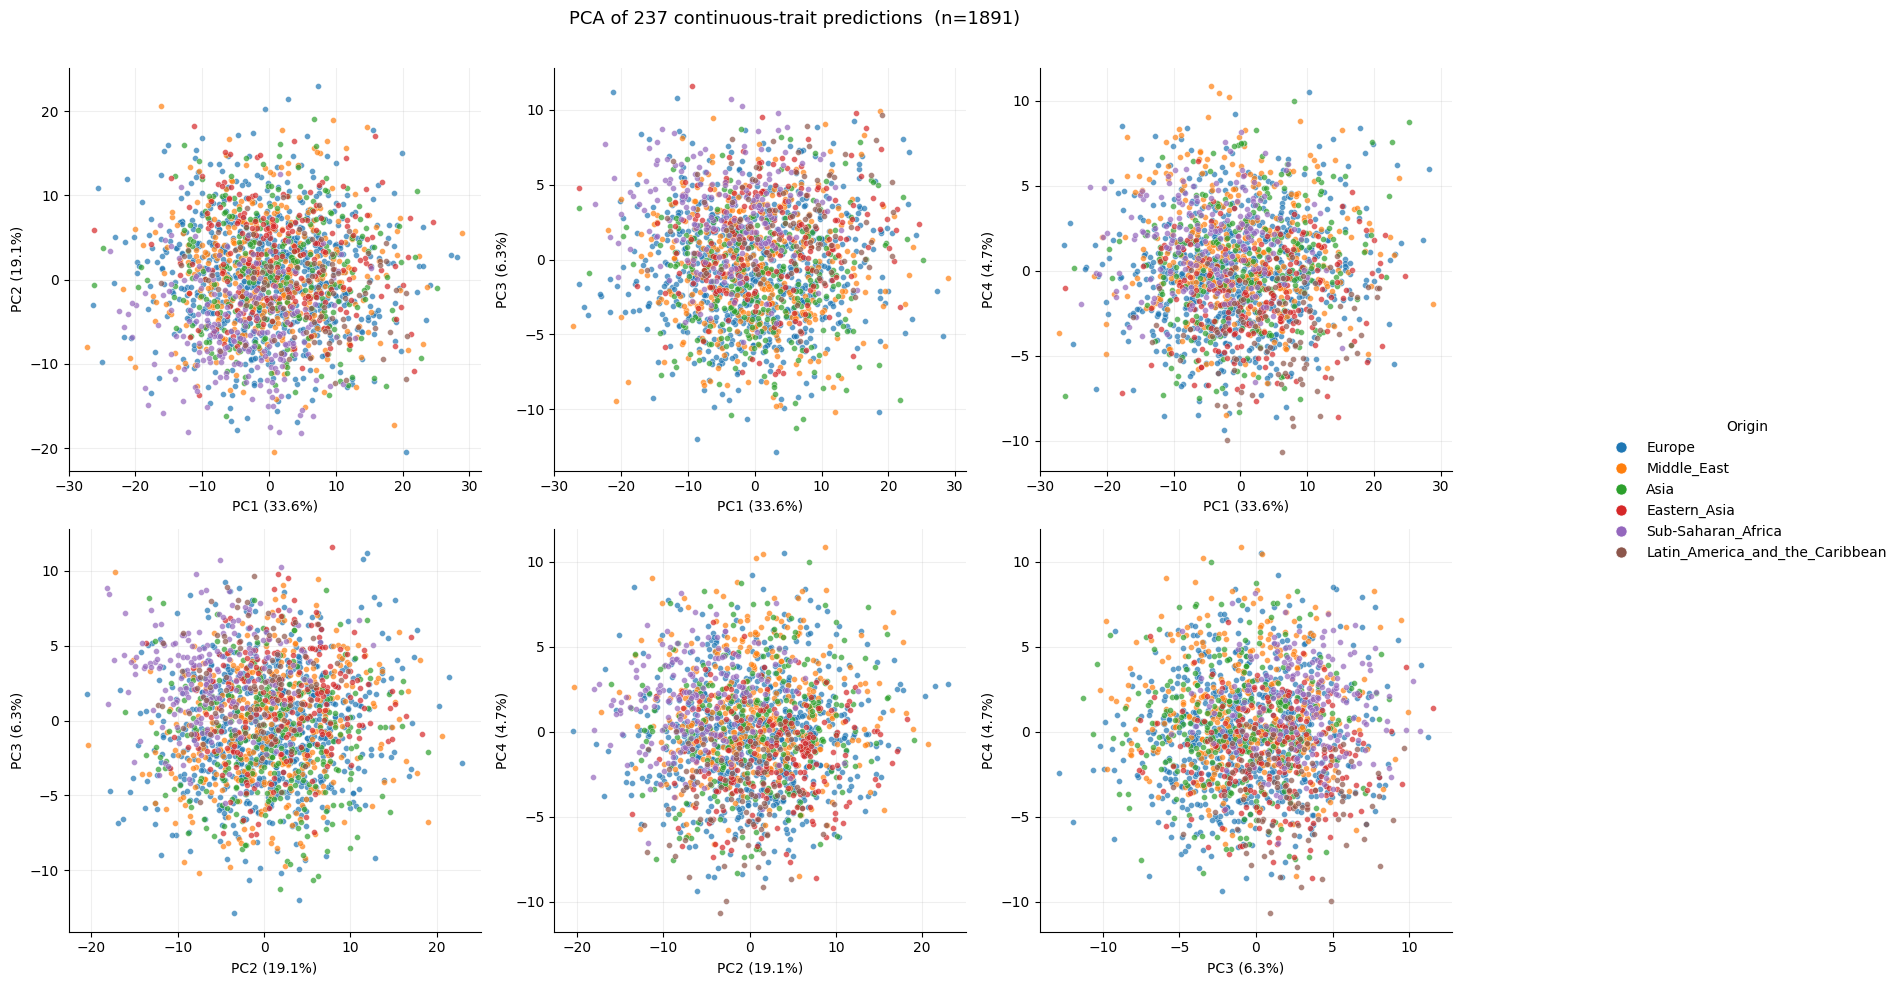

In [30]:
display(Image(filename="../docs/static/figures/example_PCA.png", width=1200))

/var/folders/mr/kxjfn6mx1kdd3j6p527gf6qw0000gn/T/ipykernel_94872/1424277131.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(um_df[f"UMAP{i}"], um_df[f"UMAP{j}"],


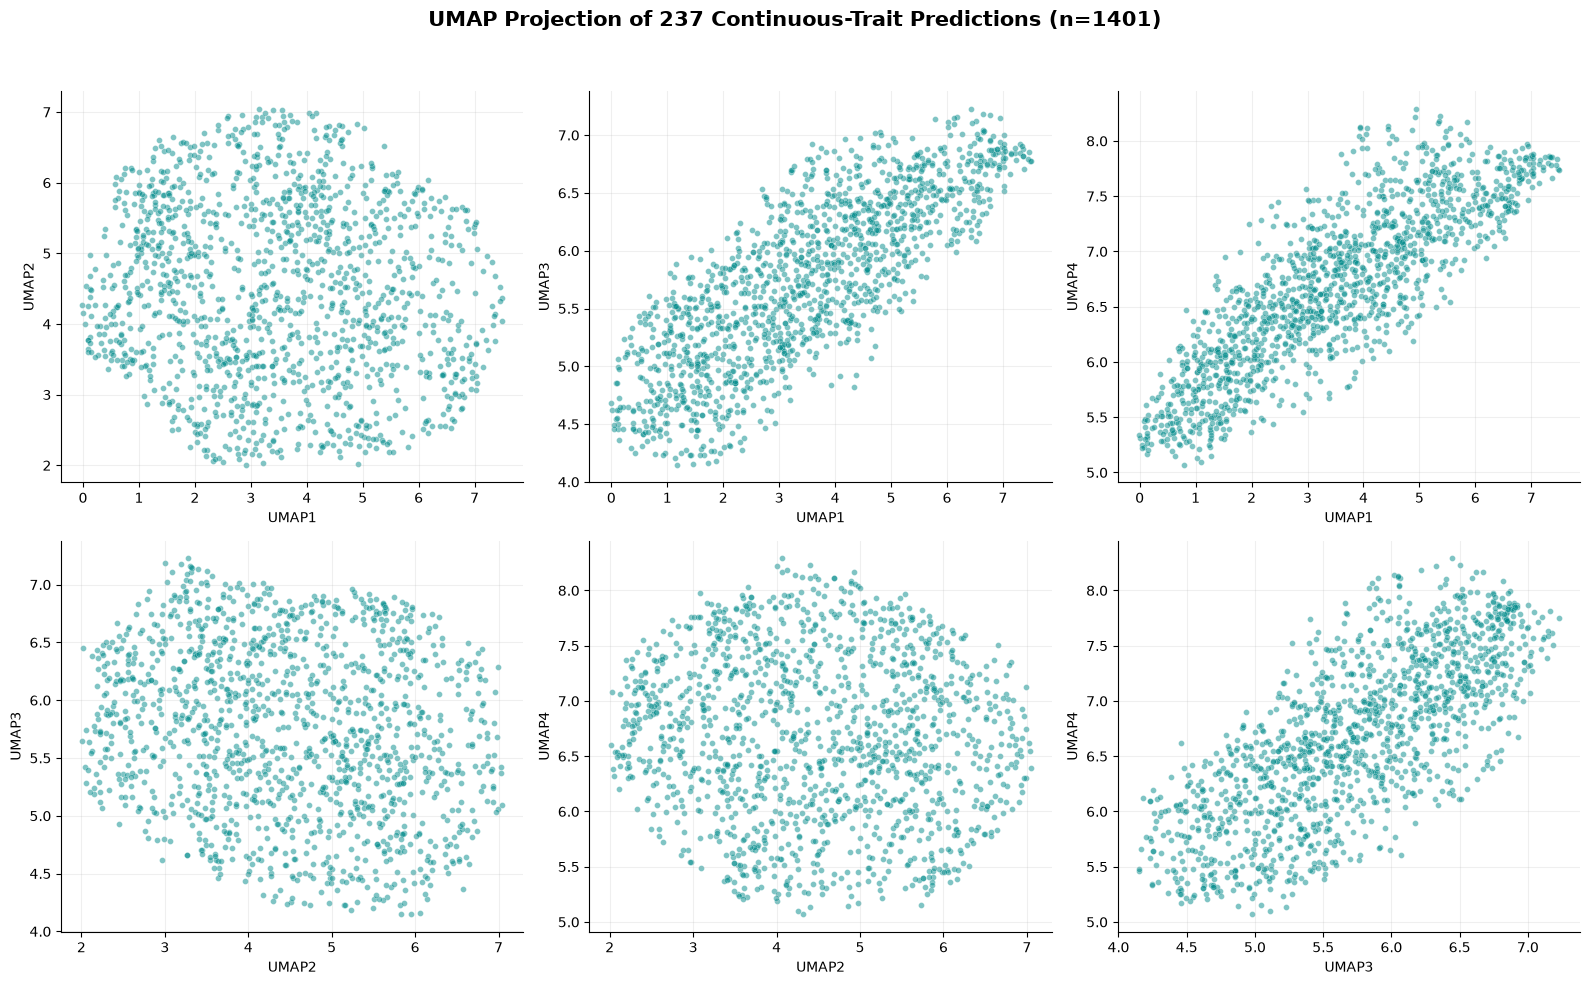

In [31]:
# To color the points, set color_by to one of the columns below and re-run this cell.
#
# Measured in PennCATH, from `labels`:
#     color_by = labels["sex"]     # 1 = male, 2 = female
#     color_by = labels["age"]
#     color_by = labels["CAD"]     # 0 = control, 1 = case
#     color_by = labels["hdl"]     # also "tg" and "ldl", missing for some individuals
#
# Predicted by the model, any of the 315 columns in `preds`:
#     color_by = preds["Standing_height"]
#     color_by = preds["I25"]      # predicted probability of chronic ischaemic heart disease
#
color_by = None

import umap

reducer = umap.UMAP(n_components=4, n_neighbors=30, min_dist=0.3,
                    metric="euclidean", random_state=42, n_jobs=1)

emb = reducer.fit_transform(X)
um_df = pd.DataFrame(emb, columns=[f"UMAP{i+1}" for i in range(4)], index=X_df.index)

pairs = list(combinations(range(1, 5), 2))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

point_color = color_by.reindex(X_df.index) if color_by is not None else "darkcyan"

for ax, (i, j) in zip(axes.flat, pairs):
    ax.scatter(um_df[f"UMAP{i}"], um_df[f"UMAP{j}"],
               s=18, alpha=0.5, linewidth=0.3,
               edgecolor="white", c=point_color, cmap="viridis")
    
    ax.set_xlabel(f"UMAP{i}")
    ax.set_ylabel(f"UMAP{j}")
    
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2)

fig.suptitle(f"UMAP Projection of {X_df.shape[1]} Continuous-Trait Predictions (n={len(um_df)})",
             fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

*For reference: UMAP of the same predictions on the **Human Origins** dataset. UMAP picks up faint structure that PCA missed, but populations still overlap heavily. The two plots (PCA, UMAP) together tell a consistent story: the model's trait predictions carry only a faint trace of ancestry. UMAP is more sensitive to this kind of weak non-linear signal than PCA, which is exactly why running both is useful.*

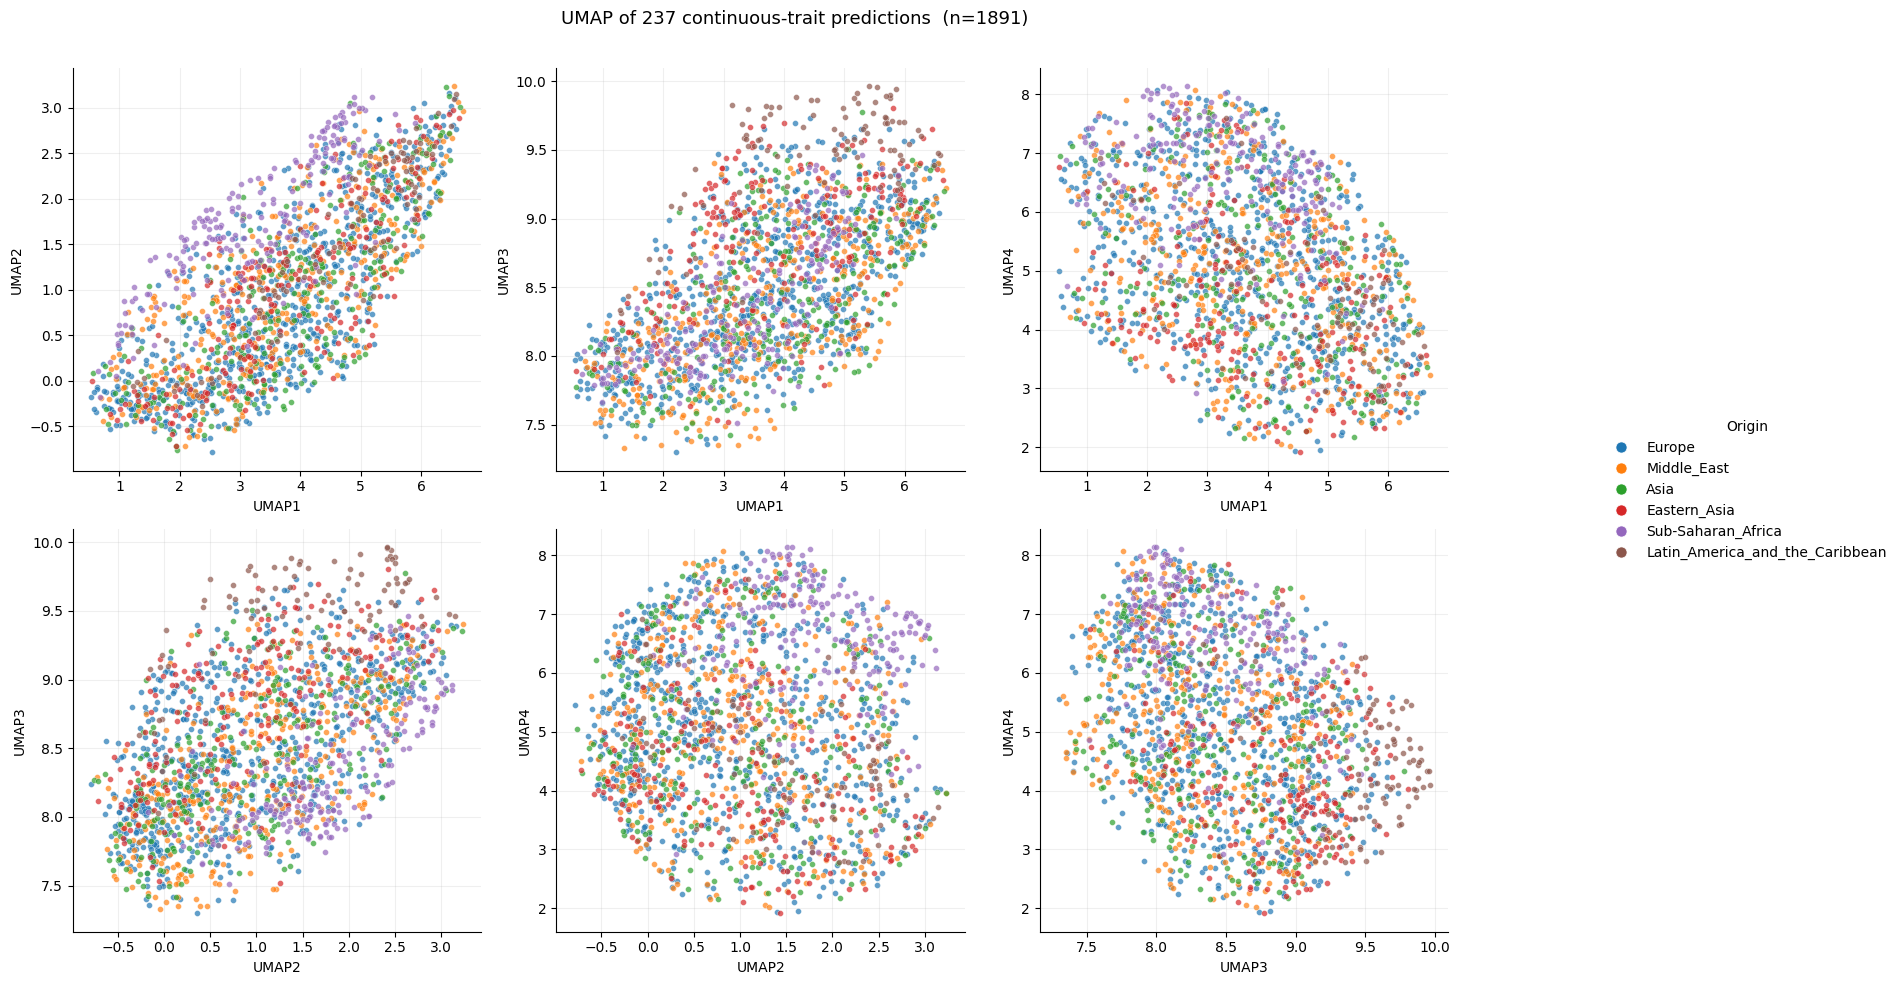

In [32]:
display(Image(filename="../docs/static/figures/example_UMAP.png", width=1200))

## 4.10 Downstream CAD prediction with the GRSs

Up to this point we have used the model's trait predictions in two different ways. We compared a handful of them (TG, HDL, LDL, and the CAD risk score) *directly* against measured PennCATH phenotypes, since those were the only traits with ground truth available. And we used the full ~237 continuous predictions *as a whole* in the clustering and PCA/UMAP step to look at their internal structure.

What we haven't done yet is ask whether the full panel of predictions, treated as features, can sharpen *CAD prediction* beyond what age + sex + the single CAD GRS already give us. That is the question this section addresses.

The plan:

1. **Reduce noise with Lasso.** With 315 candidate predictions and only ~1100 training samples, fitting any model directly will overfit. We use L1-penalized logistic regression as a feature selector to keep only a handful of the most CAD-informative predictions.
2. **Compare scenarios.** We train three classifiers (LogReg, RandomForest, XGBoost) under six feature combinations — from `Covs` only (baseline) up to `Covs + all selected GRSs`. The heatmap and bootstrap CI tell us which combinations actually help.
3. **Best-model deep dive.** We pick the top scenario and look at its ROC, precision-recall, and confusion matrix on the held-out test set.

In [33]:
# !uv pip install shap
# !uv pip install xgboost
# !uv pip install lightgbm

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectFromModel

from scipy.stats import loguniform, randint, uniform

import shap
import warnings

# Ignore unnecessary warnings for a cleaner output
warnings.filterwarnings("ignore")

Train data shape: (1120, 317)
Test data shape: (281, 317)
Selecting features using Lasso (C=0.03)...
Selected 7 features from 315 original features.

--- Running Model: LogisticRegression ---
  > Analyzing Scenario: CAD GRS (Features: 1)


  > Analyzing Scenario: all GRSs (Features: 7)
  > Analyzing Scenario: Covs (Features: 2)
  > Analyzing Scenario: Covs + CAD GRS (Features: 3)
  > Analyzing Scenario: Covs + all GRSs (Features: 9)
  > Analyzing Scenario: Covs + all but CAD GRS (Features: 8)



--- Running Model: RandomForest ---
  > Analyzing Scenario: CAD GRS (Features: 1)


  > Analyzing Scenario: all GRSs (Features: 7)


  > Analyzing Scenario: Covs (Features: 2)


...

  > Analyzing Scenario: Covs (Features: 2)


  > Analyzing Scenario: Covs + CAD GRS (Features: 3)


  > Analyzing Scenario: Covs + all GRSs (Features: 9)


  > Analyzing Scenario: Covs + all but CAD GRS (Features: 8)



--- Final Results (Top 10) ---
                Model                Scenario       AUC
0             XGBoost         Covs + all GRSs  0.845147
1             XGBoost          Covs + CAD GRS  0.841876
2        RandomForest         Covs + all GRSs  0.829901
3             XGBoost  Covs + all but CAD GRS  0.824440
4  LogisticRegression          Covs + CAD GRS  0.823586
5  LogisticRegression         Covs + all GRSs  0.821254
6  LogisticRegression                    Covs  0.815309
7  LogisticRegression  Covs + all but CAD GRS  0.815053
8        RandomForest  Covs + all but CAD GRS  0.813119
9        RandomForest          Covs + CAD GRS  0.807088


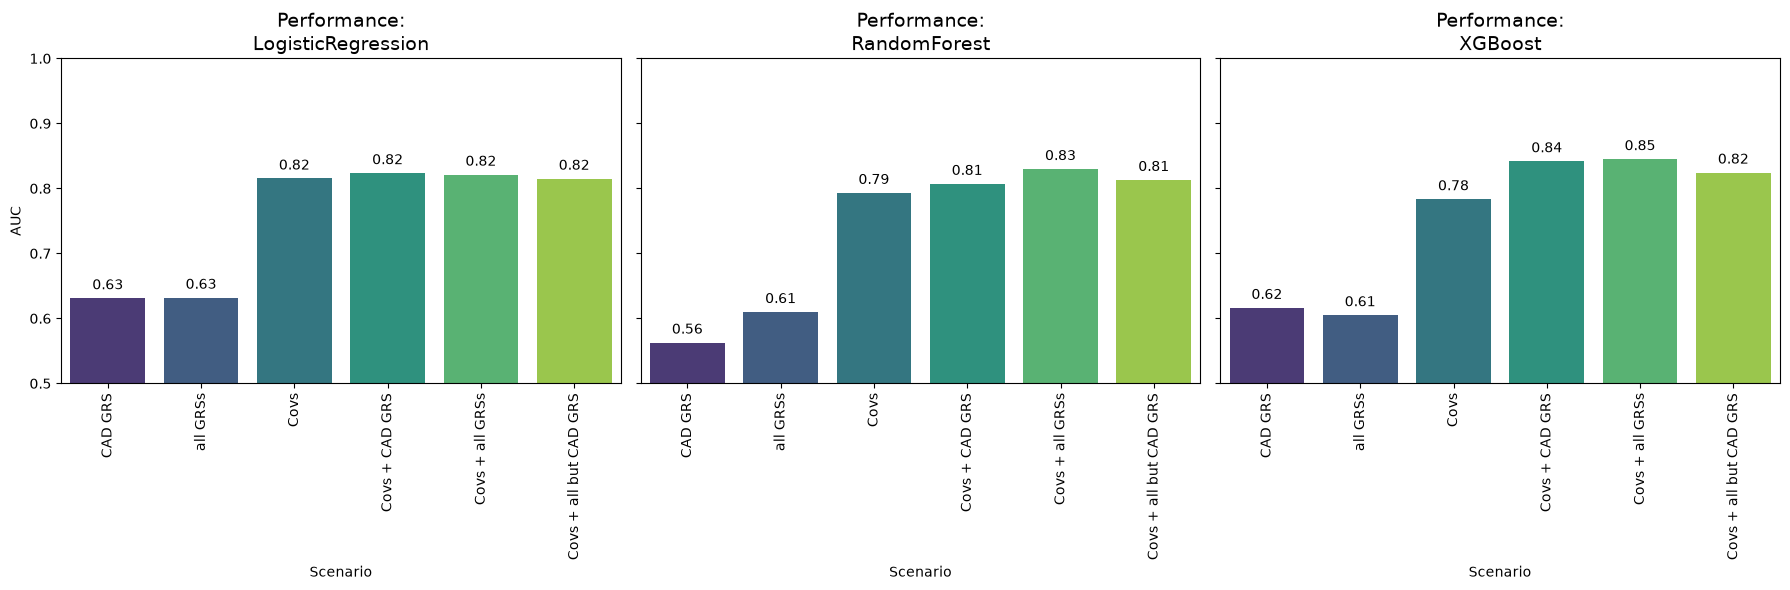

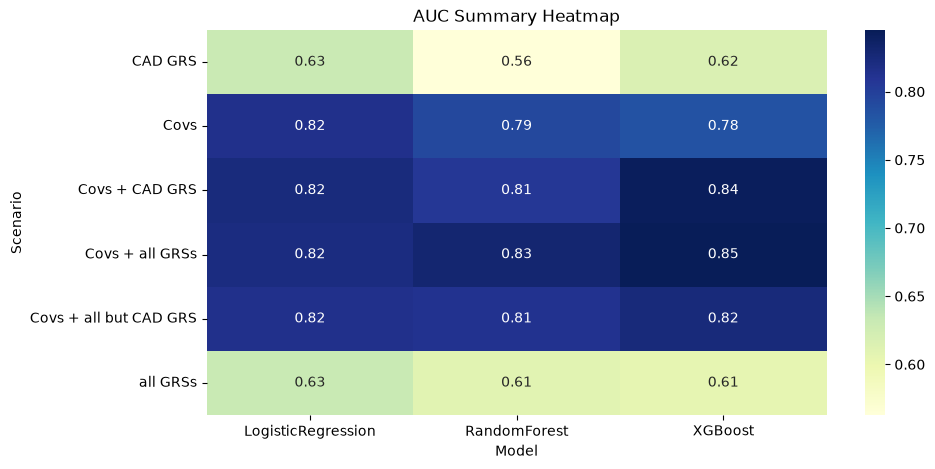

In [34]:
# ==========================================
# 1. Feature Selection (Lasso L1)
# ==========================================
def perform_feature_selection(X_train, y_train, C_val=0.05):
    """
    Selects top features using Lasso (L1) regularization to reduce noise.
    SelectFromModel: Selects important features using Lasso (L1 penalty).
    High C means more features, Low C means fewer features.
    """
    print(f"Selecting features using Lasso (C={C_val})...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Use Logistic Regression with L1 penalty for selection
    selector_model = LogisticRegression(penalty='l1', solver='liblinear', C=C_val, random_state=42)
    selector = SelectFromModel(selector_model)
    selector.fit(X_train_scaled, y_train)
    
    selected_features = X_train.columns[selector.get_support()].tolist()
    print(f"Selected {len(selected_features)} features from {X_train.shape[1]} original features.")
    return selected_features


# ==========================================
# 2. Setup Scenarios
# ==========================================
df = preds.join(labels[['CAD', 'sex', 'age']], how='inner')
df = df.dropna(subset=['CAD'])

# Define Variables
COVARIATES = ['sex', 'age']
CAD_GRS_COL = "I25"  # Actual target GRS name
y = df['CAD'].astype(int)
X = df.drop(columns=['CAD'])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train data shape: {X_train_raw.shape}")
print(f"Test data shape: {X_test_raw.shape}")

# Feature Selection execution
grs_cols = [c for c in X_train_raw.columns if c not in COVARIATES]
selected_grs = perform_feature_selection(X_train_raw[grs_cols], y_train, C_val=0.03)

# Define ALL Scenarios
scenarios = {
    "CAD GRS": [CAD_GRS_COL],

    "all GRSs": selected_grs,

    "Covs": COVARIATES,
    "Covs + CAD GRS": COVARIATES + [CAD_GRS_COL],

    # --- Selected Features (Lasso) ---
    "Covs + all GRSs": COVARIATES + selected_grs,
    "Covs + all but CAD GRS": COVARIATES + [f for f in selected_grs if f != CAD_GRS_COL],
    
    # --- Single Feature ---
}

# ==========================================
# 3. Training & Evaluation Function
# ==========================================
def evaluate_scenario(model_obj, param_grid, n_iter, scenario_name, feature_list, X_tr, X_te, y_tr, y_te):
    print(f"  > Analyzing Scenario: {scenario_name} (Features: {len(feature_list)})")
    
    X_tr_sub = X_tr[feature_list]
    X_te_sub = X_te[feature_list]
    
    # Hyperparameter Tuning
    search = RandomizedSearchCV(model_obj, param_grid, n_iter=n_iter, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
    #search = RandomizedSearchCV(model_obj, param_grid, n_iter=10, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
    search.fit(X_tr_sub, y_tr)
    best_model = search.best_estimator_
    
    # Calculate AUC
    probs = best_model.predict_proba(X_te_sub)[:, 1]
    auc_score = roc_auc_score(y_te, probs)
    
    return auc_score, best_model
    
# ==========================================
# 4. Model Training Loop
# ==========================================

models = {
    "LogisticRegression": (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                solver='saga',
                penalty='elasticnet',
                max_iter=5000,
                random_state=42
            ))
        ]),
        {
            'model__C': loguniform(1e-3, 1e2),
            'model__l1_ratio': uniform(0, 1)
        },
        5
    ),

    "RandomForest": (
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),
        {
            'n_estimators': randint(200, 800),
            'max_depth': [5, 10, 15, 20, 30],
            'min_samples_split': randint(2, 15),
            'min_samples_leaf': randint(1, 8),
            'max_features': ['sqrt', 'log2', 0.5]
        },
        5
    ),

    "XGBoost": (
        XGBClassifier(
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ),
        {
            'n_estimators': randint(200, 1000),
            'learning_rate': loguniform(1e-3, 2e-1),
            'max_depth': randint(3, 10),
            'min_child_weight': randint(1, 10),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4),
            'gamma': uniform(0, 5),
            'reg_alpha': loguniform(1e-3, 10),
            'reg_lambda': loguniform(1e-3, 10)
        },
        10
    )
}

results_list = []

for model_name, (model_obj, params, n_iter) in models.items():
    print(f"\n--- Running Model: {model_name} ---")
    for sc_name, feature_list in scenarios.items():
        auc_score, best_model = evaluate_scenario(
            model_obj, params, n_iter, sc_name, feature_list, 
            X_train_raw, X_test_raw, y_train, y_test
        )
        
        if auc_score is not None:
            results_list.append({
                "Model": model_name, 
                "Scenario": sc_name, 
                "AUC": auc_score,
                "Best_Model": best_model,
                "Best_Params": str(best_model.get_params())
            })

# Display clean results DataFrame
res_df = pd.DataFrame(results_list)
print("\n--- Final Results (Top 10) ---")
display_df = res_df.drop(columns=['Best_Params', 'Best_Model']).sort_values(by="AUC", ascending=False).reset_index(drop=True)
print(display_df.head(10))

# ==========================================
# 5. Visualization
# ==========================================
plt.rc('font', family='sans-serif')

unique_models = res_df['Model'].unique()
fig, axes = plt.subplots(1, len(unique_models), figsize=(18, 6), sharey=True)

# Ensure axes is iterable even if only one model is used
if len(unique_models) == 1:
    axes = [axes]

for i, m_name in enumerate(unique_models):
    data_sub = res_df[res_df['Model'] == m_name]
    sns.barplot(data=data_sub, x='Scenario', y='AUC', ax=axes[i], palette='viridis')
    axes[i].set_title(f"Performance:\n{m_name}", fontsize=14)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)
    axes[i].set_ylim(0.5, 1.0)
    
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
pivot_df = res_df.pivot(index="Scenario", columns="Model", values="AUC")
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("AUC Summary Heatmap")
plt.show()

**Using the hyperparameters from a longer search**

The search above only draws a few parameter sets per model, so that it finishes in a minute
or two and we can get through it in the session. A longer search takes around eight minutes,
so instead of running it here we can simply reuse the hyperparameters it found. The cell
below reads them from `pretrained/eir-fm/ml_best_params.json` and refits the 18 models,
which takes a few seconds since there is no cross-validation left to do.

Comment the cell out if you want to carry on with the models your own search just found.

In [35]:
import json
from sklearn.base import clone

with open("../pretrained/eir-fm/ml_best_params.json") as fh:
    longer_search = json.load(fh)

model_objs = {name: obj for name, (obj, _, _) in models.items()}

results_list = []
for rec in longer_search["results"]:
    features = scenarios[rec["scenario"]]
    model = clone(model_objs[rec["model"]]).set_params(**rec["params"])
    model.fit(X_train_raw[features], y_train)

    probs = model.predict_proba(X_test_raw[features])[:, 1]
    results_list.append({
        "Model": rec["model"],
        "Scenario": rec["scenario"],
        "AUC": roc_auc_score(y_test, probs),
        "Best_Model": model,
        "Best_Params": str(rec["params"]),
    })

res_df = pd.DataFrame(results_list)
print(res_df.drop(columns=["Best_Params", "Best_Model"])
            .sort_values("AUC", ascending=False)
            .reset_index(drop=True)
            .head(10))

                Model                Scenario       AUC
0        RandomForest          Covs + CAD GRS  0.845688
1             XGBoost          Covs + CAD GRS  0.843327
2             XGBoost         Covs + all GRSs  0.841905
3        RandomForest         Covs + all GRSs  0.841734
4  LogisticRegression          Covs + CAD GRS  0.826317
5             XGBoost  Covs + all but CAD GRS  0.824440
6  LogisticRegression         Covs + all GRSs  0.820628
7        RandomForest  Covs + all but CAD GRS  0.818808
8  LogisticRegression                    Covs  0.815309
9  LogisticRegression  Covs + all but CAD GRS  0.814029


### 4.10.1 Bootstrap CI: are the scenario differences statistically meaningful?

In the heatmap above, `Covs + CAD GRS` (3 features) sometimes beats `Covs + all GRSs` (9 features) by a tiny margin for LR and RF — which is counterintuitive since the latter is a feature superset. With only n=281 in the test set, those gaps may simply be noise from a single train/test split.

To check, we bootstrap the test set (resample with replacement, 1000 iterations) on the already-trained best models and compute a 95% CI on AUC for each (model, scenario) pair. If the CIs overlap heavily, the ranking differences are within noise; if they don't, the differences are real.

--- Bootstrap 95% CI on test-set AUC (1000 resamples) ---


,Model,Scenario,AUC_point,AUC_mean,AUC_lower,AUC_upper
0,RandomForest,Covs + CAD GRS,0.8457,0.8452,0.7951,0.8917
1,XGBoost,Covs + CAD GRS,0.8433,0.8431,0.7933,0.8896
2,RandomForest,Covs + all GRSs,0.8417,0.8431,0.7934,0.8891
3,XGBoost,Covs + all GRSs,0.8419,0.8429,0.7882,0.8878
4,LogisticRegression,Covs + CAD GRS,0.8263,0.8267,0.7722,0.8751
5,XGBoost,Covs + all but CAD GRS,0.8244,0.8228,0.7708,0.8730
6,LogisticRegression,Covs + all GRSs,0.8206,0.8199,0.7661,0.8675
7,RandomForest,Covs + all but CAD GRS,0.8188,0.8189,0.7597,0.8724
8,LogisticRegression,Covs,0.8153,0.8158,0.7608,0.8645
9,LogisticRegression,Covs + all but CAD GRS,0.8140,0.8154,0.7625,0.8667


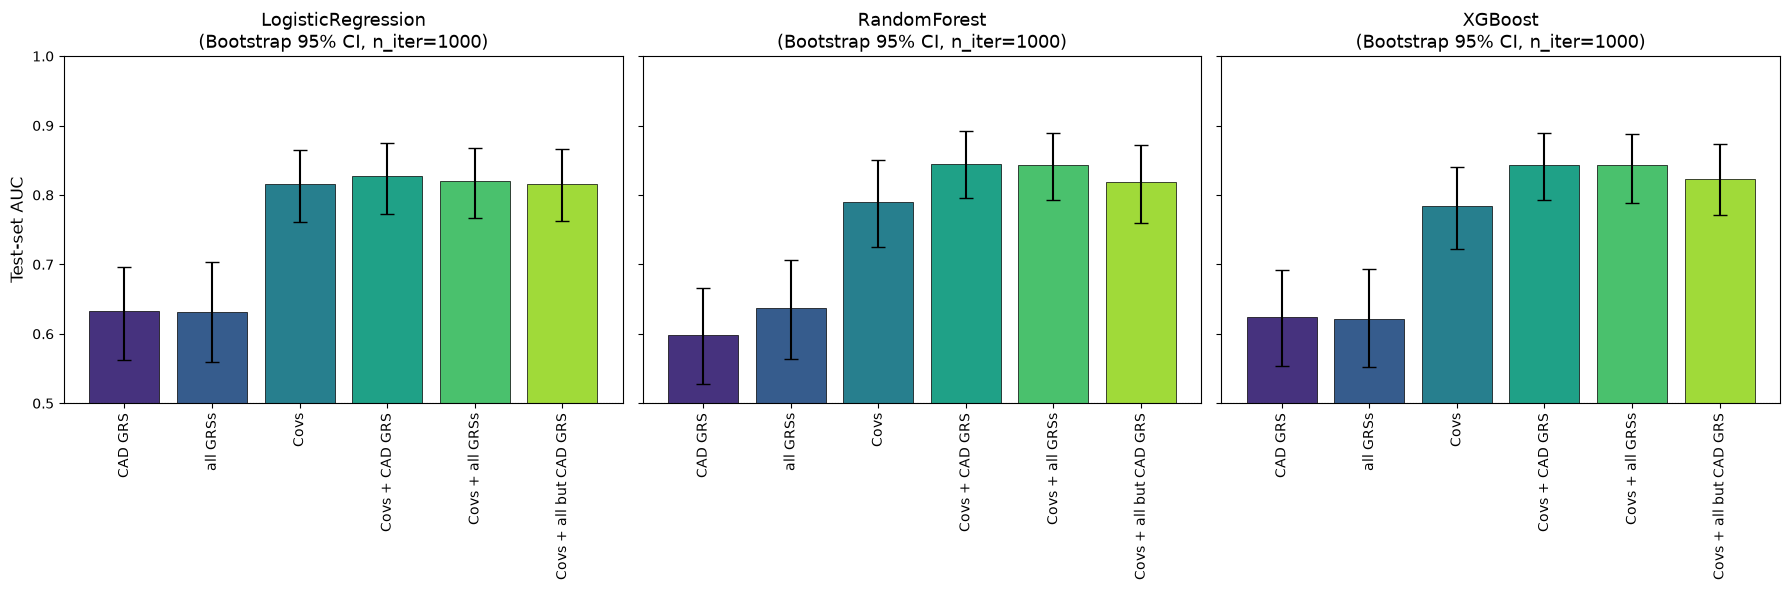

In [36]:
# ==========================================
# Bootstrap 95% CI on test-set AUC
# Reuses already-trained Best_Model from res_df
# ==========================================
rng = np.random.default_rng(42)
n_bootstrap = 1000
y_te_arr = y_test.values
n_test = len(y_te_arr)

boot_records = []
for _, row in res_df.iterrows():
    model = row['Best_Model']
    feature_list = scenarios[row['Scenario']]
    probs = model.predict_proba(X_test_raw[feature_list])[:, 1]

    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n_test, n_test)
        if len(np.unique(y_te_arr[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_te_arr[idx], probs[idx]))

    boot_records.append({
        'Model': row['Model'],
        'Scenario': row['Scenario'],
        'AUC_point': row['AUC'],
        'AUC_mean': np.mean(aucs),
        'AUC_lower': np.percentile(aucs, 2.5),
        'AUC_upper': np.percentile(aucs, 97.5),
    })

boot_df = pd.DataFrame(boot_records)
print('--- Bootstrap 95% CI on test-set AUC (1000 resamples) ---')
display(boot_df.sort_values('AUC_mean', ascending=False).reset_index(drop=True).round(4))

# Bar plot with error bars per model
unique_models = boot_df['Model'].unique()
scenario_order = list(scenarios.keys())
fig, axes = plt.subplots(1, len(unique_models), figsize=(18, 6), sharey=True)
if len(unique_models) == 1:
    axes = [axes]

for ax, m_name in zip(axes, unique_models):
    sub = boot_df[boot_df['Model'] == m_name].set_index('Scenario').loc[scenario_order].reset_index()
    err_lower = sub['AUC_mean'] - sub['AUC_lower']
    err_upper = sub['AUC_upper'] - sub['AUC_mean']
    colors = sns.color_palette('viridis', len(sub))
    ax.bar(range(len(sub)), sub['AUC_mean'], yerr=[err_lower, err_upper],
           capsize=5, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['Scenario'], rotation=90)
    ax.set_title(f'{m_name}\n(Bootstrap 95% CI, n_iter=1000)', fontsize=13)
    ax.set_ylim(0.5, 1.0)
    ax.axhline(0.5, color='gray', linestyle=':', lw=0.8)
axes[0].set_ylabel('Test-set AUC', fontsize=12)
plt.tight_layout()
plt.show()

## 4.11 SHAP analysis

The previous section told us *that* the model works (AUC numbers, scenario comparison). This section asks *why* it works.

Now that our model demonstrates improved performance over the age and sex baseline, we aim to interpret its decision-making process. SHAP (SHapley Additive exPlanations) enables this by calculating how much each feature increases or decreases an individual's predicted CAD risk relative to the average. Through this method, we focus on identifying and highlighting the top contributing features that have the greatest impact on the predictions.

We analyze two scenarios in parallel:

- **Best Overall Model** (`Covs + all GRSs`) — the strongest setup from the comparison above. Age and sex are likely to dominate, since the heatmap showed covariates alone already reach AUC ≈ 0.82.
- **Pure GRS Model** (`all GRSs`, no age/sex) — strips out the covariates so we can see what the model's *trait predictions alone* contribute. Useful for asking "is there a genetic signal beyond demographics?"

Three SHAP views below:

| Plot | Question it answers |
|---|---|
| **Summary (dot)** | Which features matter most globally, and is high feature value associated with higher or lower CAD risk? Each dot is one individual; color = feature value. |
| **Feature importance (bar)** | A simpler ranked view: mean absolute SHAP value per feature. |
| **Waterfall (local)** | For one specific individual (here, the highest-risk patient), which features pushed their score up or down? Useful for sanity-checking the model on a real case. |



Starting Analysis: Best Overall Model
Model: RandomForest | Scenario: Covs + all GRSs


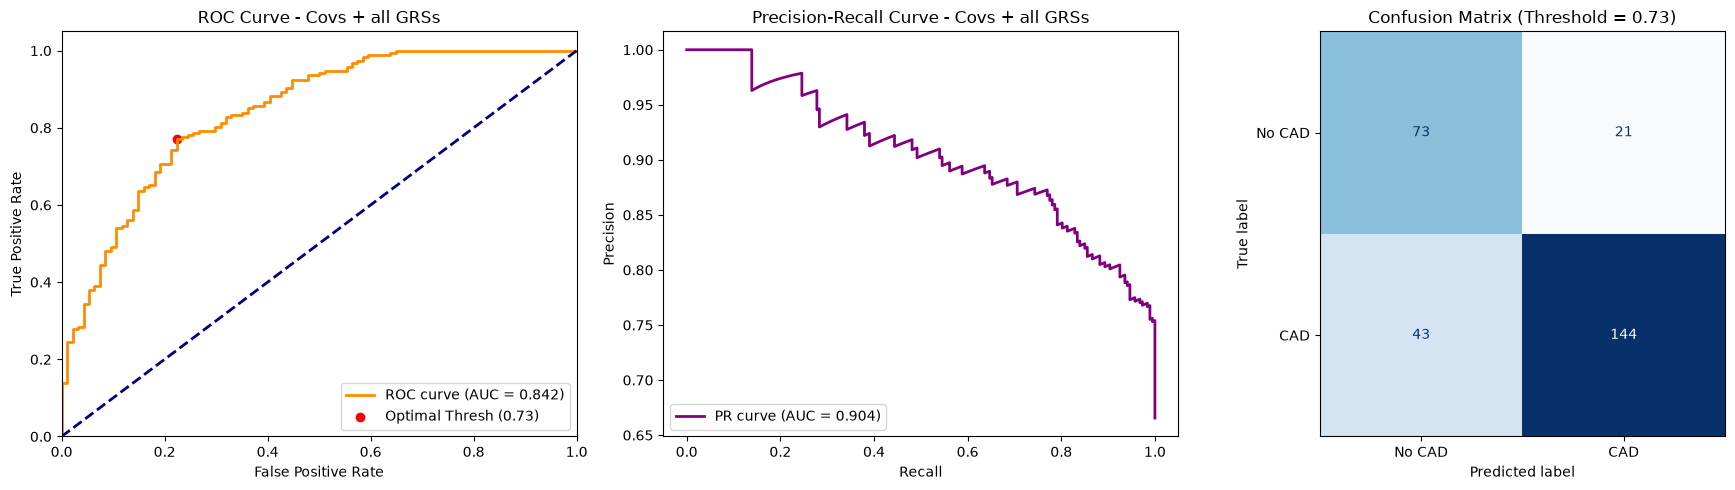

Background dataset has 281 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=281 when initializing the masker.



SHAP-based Interpretation (RandomForest / Covs + all GRSs)


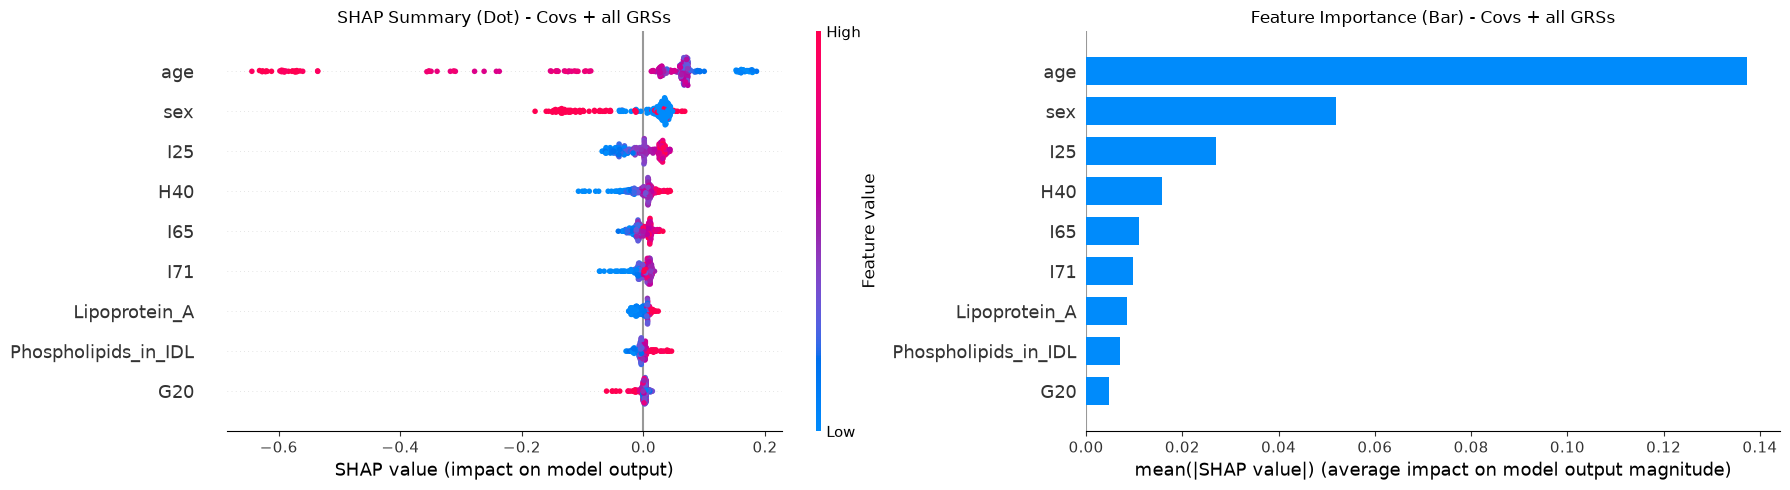

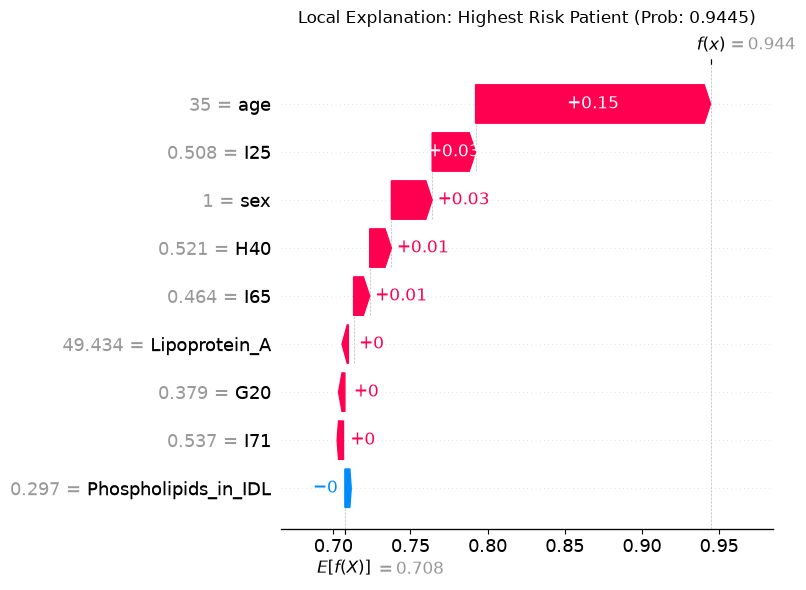


Starting Analysis: Pure GRS Model (Excluding Age & Sex)
Model: RandomForest | Scenario: all GRSs


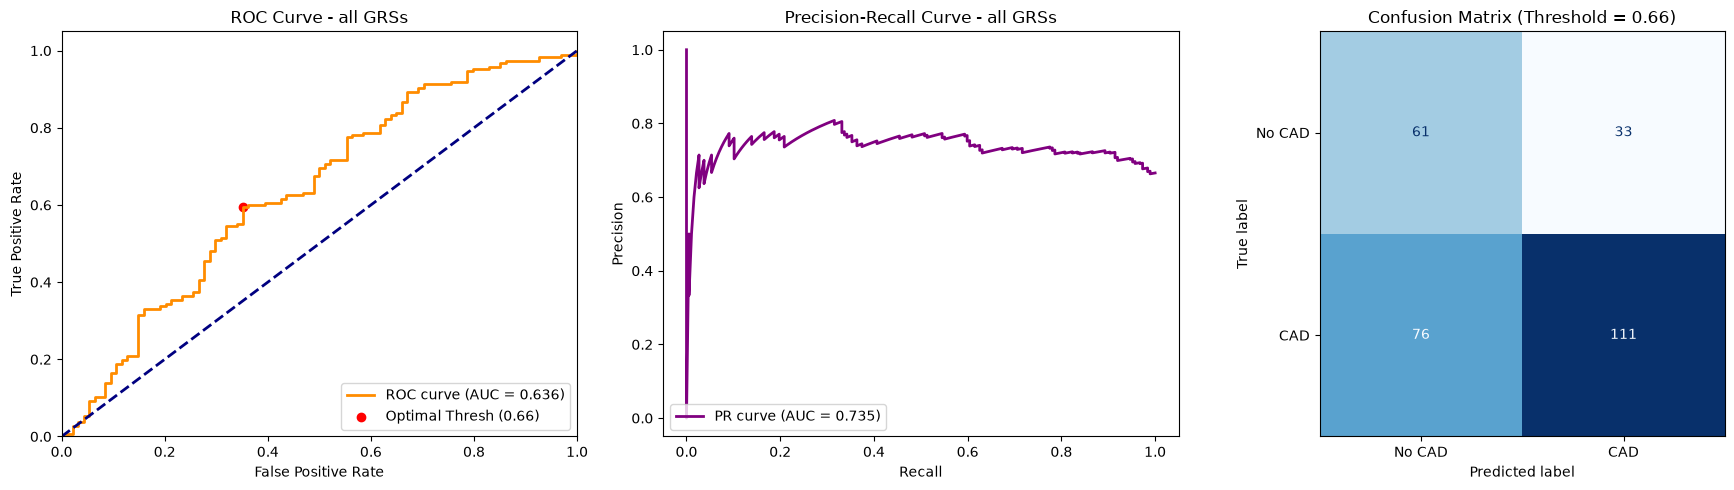

Background dataset has 281 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=281 when initializing the masker.



SHAP-based Interpretation (RandomForest / all GRSs)


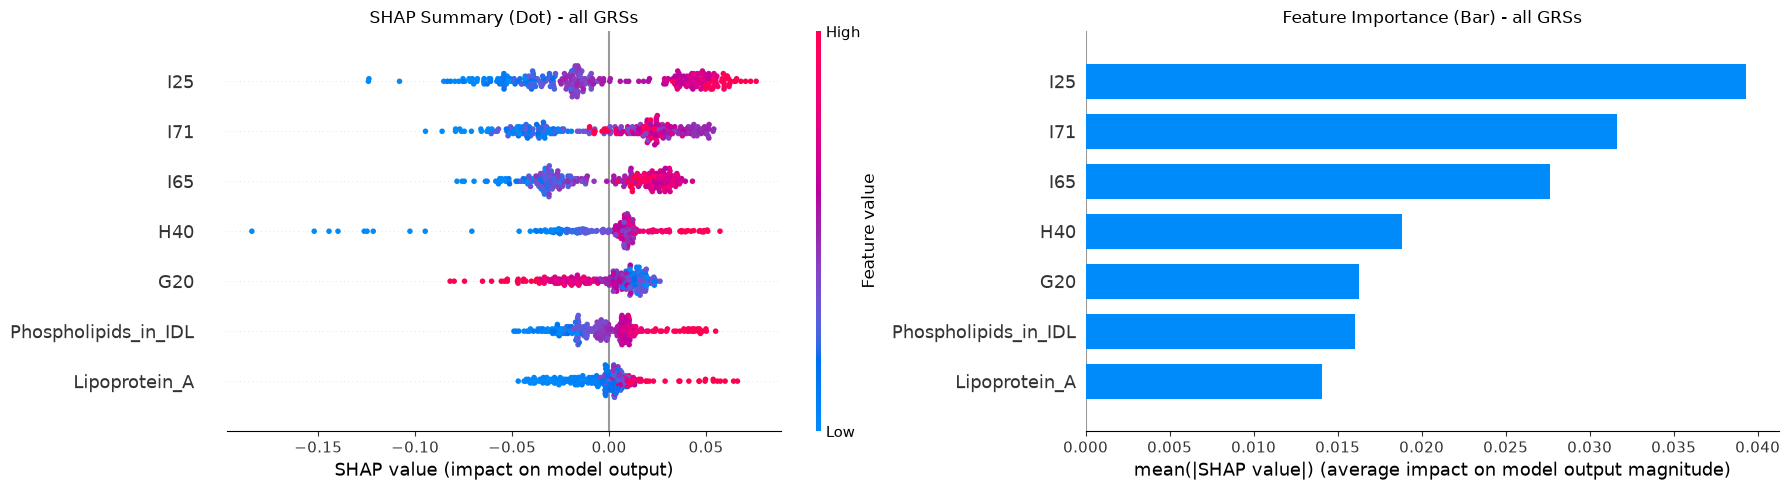

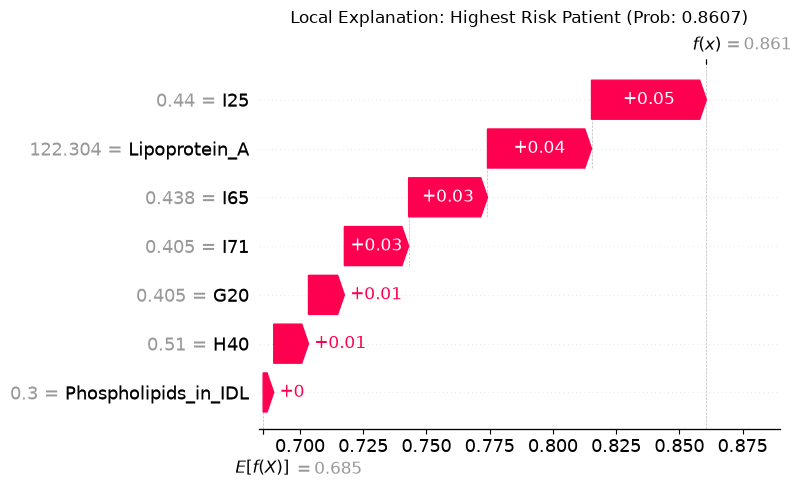

In [37]:
# =====================================================================
# 6. Analysis (Best Model & Pure GRS)
# =====================================================================
# best_idx = res_df['AUC'].idxmax()
# best_model_name = res_df.loc[best_idx, 'Model']
# best_scenario_name = res_df.loc[best_idx, 'Scenario']
best_model_name = 'RandomForest'
best_scenario_name = 'Covs + all GRSs'
pure_grs_scenario = 'all GRSs'

analysis_targets = [
    {"title": "Best Overall Model", "model_name": best_model_name, "scenario": best_scenario_name},
    {"title": "Pure GRS Model (Excluding Age & Sex)", "model_name": best_model_name, "scenario": pure_grs_scenario}
]

for target in analysis_targets:
    print("\n" + "="*60)
    print(f"Starting Analysis: {target['title']}")
    print(f"Model: {target['model_name']} | Scenario: {target['scenario']}")
    print("="*60)

    # Extract model and features directly from previously trained results
    result_dict = next(item for item in results_list if item["Model"] == target["model_name"] and item["Scenario"] == target["scenario"])
    model_obj = result_dict["Best_Model"]
    features = scenarios[target["scenario"]]

    X_test_target = X_test_raw[features]
    y_prob = model_obj.predict_proba(X_test_target)[:, 1]
    target_auc = roc_auc_score(y_test, y_prob)

    # --- Integrated Performance Graphs ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {target_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'ROC Curve - {target["scenario"]}')
    axes[0].legend(loc="lower right")

    J = tpr - fpr
    best_thresh_idx = np.argmax(J)
    best_thresh = thresholds[best_thresh_idx]
    axes[0].scatter(fpr[best_thresh_idx], tpr[best_thresh_idx], marker='o', color='red', label=f'Optimal Thresh ({best_thresh:.2f})')
    axes[0].legend(loc="lower right")

    # 2) Precision-Recall Curve
    precision, recall, pr_thresh = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'Precision-Recall Curve - {target["scenario"]}')
    axes[1].legend(loc="lower left")

    # 3) Confusion Matrix
    y_pred_optimal = (y_prob >= best_thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_optimal)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No CAD", "CAD"])
    disp.plot(cmap=plt.cm.Blues, ax=axes[2], colorbar=False)
    axes[2].set_title(f"Confusion Matrix (Threshold = {best_thresh:.2f})")

    plt.tight_layout()
    plt.show()

    # --- SHAP Analysis ---
    print(f"\nSHAP-based Interpretation ({target['model_name']} / {target['scenario']})")
    
    if hasattr(model_obj, 'named_steps'):
        model_for_shap = model_obj.named_steps['model']
        if 'scaler' in model_obj.named_steps:
            X_test_shap = pd.DataFrame(
                model_obj.named_steps['scaler'].transform(X_test_target), 
                columns=X_test_target.columns
            )
        else:
            X_test_shap = X_test_target
    else:
        model_for_shap = model_obj
        X_test_shap = X_test_target

    explainer = shap.Explainer(model_for_shap, X_test_shap)
    shap_obj = explainer(X_test_shap)
    shap_values = shap_obj.values

    if isinstance(shap_values, list):
        shap_values = shap_values[1]
        shap_obj = shap_obj[..., 1]
    elif len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]
        shap_obj = shap_obj[:, :, 1]

    # Summary Plots
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 2, 1)
    shap.summary_plot(shap_values, X_test_shap, show=False, plot_size=None)
    plt.title(f"SHAP Summary (Dot) - {target['scenario']}")

    plt.subplot(1, 2, 2)
    shap.summary_plot(shap_values, X_test_shap, plot_type="bar", show=False, plot_size=None)
    plt.title(f"Feature Importance (Bar) - {target['scenario']}")

    plt.tight_layout()
    plt.show()

    # Waterfall Plot (Highest Risk Patient)
    highest_risk_idx = np.argmax(y_prob)

    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(shap_obj[highest_risk_idx], max_display=10, show=False)
    plt.title(f"Local Explanation: Highest Risk Patient (Prob: {y_prob[highest_risk_idx]:.4f})", pad=10)
    plt.tight_layout()
    plt.show()

# 5. Summary

- **From PGS to a foundation model.** Classical PGS is one trait at a time, and a second
  trait means starting over. This model was trained on genotypes and many phenotypes at
  once, so one pass over the PennCATH genotypes gave us 315 predicted phenotypes per
  individual.
- **SNP harmonization.** The model can only use SNPs it was trained on, so EIR matched the
  PennCATH variants against the UKB ones first. Worth checking in the log, since a poor
  overlap limits everything after it.
- **Predicted against measured lipids.** The raw correlations look modest, but that is
  genetics alone, with no age, sex or environment in the plot. Adding the prediction to an
  age and sex baseline improves on it for all three lipids, so it contains information
  *beyond* just age and sex.
- **Binary traits.** For CAD we used ROC-AUC and precision-recall rather than accuracy,
  since we rarely apply a hard classification threshold here.
- **Correlations between the predicted traits.** Traits we would expect to be related
  cluster together, which suggests the model picked up something biological.
- **Individuals in 2D.** PCA and UMAP place each person on a plot from their 315
  predictions. Coloring the points by something in `labels` or `preds` is how we see what
  that layout corresponds to. PennCATH has no ancestry column, so for ancestry we used the
  Human Origins data instead, where the populations stay mixed.
- **Downstream CAD prediction.** Lasso kept 7 of the 315 traits, chosen after splitting so
  the test set cannot help pick its own features. Age and sex do most of the work in every
  scenario, and the bootstrap intervals overlap across most of the leaderboard.
- **SHAP.** Age and sex have the largest values, and the predicted traits come after them.

Two things to keep in mind. PennCATH selected younger cases and older controls, which is why
age is such a strong predictor here. And the cohort is small, so a single AUC number is not
worth much on its own.

The next notebook, `02_eir-intro.ipynb`, moves from using a pre-trained model to training one
ourselves.